# Phân Tích Dữ Liệu Spotify Vietnam Top 200

**Dự án:** Early Trajectory Prediction - Dự đoán bài hát có đạt Top 10 hay không sau tuần đầu tiên lọt bảng xếp hạng.
**Dữ liệu:** Spotify Top 200 Weekly Chart - Việt Nam
**Giai đoạn thu thập:** 18/12/2025 - 04/06/2026

---

## Mô tả dữ liệu

Bộ dữ liệu được tổ chức theo mô hình **Star Schema** gồm 4 bảng:

| Bảng | Mô tả | Ghi chú |
|---|---|---|
| `fact_top_track` | Bảng fact chứa thứ hạng, lượt stream, thời gian | 5,000 records |
| `dim_artist` | Thông tin nghệ sĩ (tên, genres, followers) | SCD Type 2 |
| `dim_track_info` | Thông tin bài hát (tên, album, thời lượng) | SCD Type 2 |
| `dim_audio_feature` | Đặc trưng âm thanh từ Spotify API | SCD Type 2 |

> **Lưu ý:** Các bảng dimension sử dụng [SCD Type 2](https://en.wikipedia.org/wiki/Slowly_changing_dimension#Type_2:_add_new_row)
> -- mỗi bản ghi có `IS_CURRENT` để phân biệt phiên bản hiện tại.

## Bài toán dự đoán
**Câu hỏi:** Sau khi bài hát lọt chart trong tuần đầu tiên, liệu bài hát có đạt được Top 10 vào những tuần kế tiếp hay không?

## 1. Import thư viện

Các thư viện được sử dụng:
- **pandas / numpy**: Xử lý và phân tích dữ liệu
- **pyarrow**: Đọc file Parquet
- **ast**: Parse chuỗi JSON (artist_id, genres)

In [44]:
import pandas as pd
import numpy as np
from functools import reduce
import pyarrow
from pathlib import Path
import ast
import seaborn as sns 
import matplotlib.pyplot as plt

## 2. Load dữ liệu

Đọc 4 file Parquet từ thư mục `data/`. Sử dụng `Path` để đảm bảo đường dẫn tương thích đa nền tảng.

In [45]:
WORKING_DIR = Path.cwd().resolve()
DATA_DIR = Path(WORKING_DIR / 'data')

In [46]:
df_artist = pd.read_parquet(f'{DATA_DIR}/dim_artist.parquet')
df_audio_feature = pd.read_parquet(f'{DATA_DIR}/dim_audio_feature.parquet')
df_track_info = pd.read_parquet(f'{DATA_DIR}/dim_track_info.parquet')
df_fact = pd.read_parquet(f'{DATA_DIR}/fact_top_track.parquet')

## 3. Tiền xử lý dữ liệu (Data Preprocessing)

### 3.1 Tạo bản sao dữ liệu gốc

Tạo bản sao (`copy()`) để giữ nguyên dữ liệu gốc, tránh ảnh hưởng khi thực hiện các biến đổi.

In [47]:
df_artist_copy = df_artist.copy()
df_audio_feature_copy = df_audio_feature.copy()
df_track_info_copy = df_track_info.copy()
df_fact_copy = df_fact.copy()

### 3.2 Xử lý bảng `dim_artist`

- Chọn các cột cần thiết, loại bỏ `DBT_VALID_FROM` và `DBT_VALID_TO` (metadata SCD)
- Chuẩn hóa tên cột sang **lowercase**
- Lọc chỉ giữ bản ghi hiện tại (`is_current == True`)

In [48]:
df_artist_copy = df_artist_copy[['ARTIST_ID','ARTIST_NAME','ARTIST_GENRES','POPULARITY','ARTIST_FOLLOWERS','IS_CURRENT']]
df_artist_copy.columns = df_artist_copy.columns.str.lower()
df_artist_copy = df_artist_copy[df_artist_copy['is_current']]
df_artist_copy

,artist_id,artist_name,artist_genres,popularity,artist_followers,is_current
0,5zqSvInhVbM7ogkSfxny2C,Wendy Thao,"[""v-pop"",""vinahouse""]",14,15032,True
1,0CO1IZAPmgTbkfXvcRCLsL,BAN,"[""v-pop"",""vietnamese hip hop""]",52,68895,True
2,5dfZ5uSmzR7VQK0udbAVpf,Sơn Tùng M-TP,"[""v-pop"",""vinahouse"",""vietnamese hip hop""]",65,6574507,True
3,0qAJ604EZMbkbpZ9NN6W6d,WOKEUP,"[""vietnamese hip hop"",""v-pop"",""vietnam indie""]",52,18087,True
5,4fIpKRkFloYWihK3672gOl,Dyteller,"[""v-pop""]",39,122,True
...,...,...,...,...,...,...
335,5zifyPCJIZxUBhVq7AydsT,Nâu,"[""""]",43,3596,True
336,4e5LAUvM35jleGg8gElTsP,Miu Lê,"[""v-pop"",""vietnamese hip hop"",""vinahouse""]",48,445864,True
337,0ZbgKh0FgPYeFP38nVaEGp,Obito,"[""v-pop"",""vietnamese hip hop"",""vietnam indie""]",64,940077,True
338,0EOMdQwzUG6CKh9oWvcANr,Lăng LD,"[""vietnamese hip hop"",""v-pop""]",45,24942,True


### 3.3 Xử lý bảng `dim_audio_feature`

- Loại bỏ các cột SCD metadata (`DBT_VALID_FROM`, `DBT_VALID_TO`)
- Chuẩn hóa tên cột sang lowercase
- Lọc bản ghi hiện tại (`is_current == True`)

**Các audio features từ Spotify API:**

| Feature | Khoảng giá trị | Ý nghĩa |
|---|---|---|
| `danceability` | 0.0 – 1.0 | Mức độ phù hợp để nhảy |
| `energy` | 0.0 – 1.0 | Cường độ và hoạt động âm nhạc |
| `valence` | 0.0 – 1.0 | Mức độ tích cực/vui vẻ |
| `acousticness` | 0.0 – 1.0 | Mức độ acoustic |
| `speechiness` | 0.0 – 1.0 | Mức độ lời nói trong bài |
| `tempo` | BPM | Nhịp độ (beats per minute) |

In [49]:
df_audio_feature_copy = df_audio_feature_copy[['TRACK_ID','ACOUSTICNESS','DANCEABILITY', 'ENERGY',
       'INSTRUMENTALNESS', 'KEY', 'LIVENESS', 'MODE', 'SPEECHINESS', 'TEMPO',
       'TIME_SIGNATURE', 'VALENCE','IS_CURRENT']]
df_audio_feature_copy.columns = df_audio_feature_copy.columns.str.lower()
df_audio_feature_copy = df_audio_feature_copy[df_audio_feature_copy['is_current']]
df_audio_feature_copy

,track_id,acousticness,danceability,energy,instrumentalness,key,liveness,mode,speechiness,tempo,time_signature,valence,is_current
0,50cmxP6KlnQA9IG3q5ckKD,0.3310,0.652,0.332,0.000000,2,0.1160,1,0.0293,113.904,4,0.2980,True
1,0eFMbKCRw8KByXyWBw8WO7,0.0899,0.529,0.469,0.000015,1,0.8310,0,0.0358,87.864,4,0.3440,True
2,27AEQr4wqfHyVpwgFgnGs6,0.4550,0.761,0.688,0.039900,11,0.1100,1,0.3090,151.874,4,0.2900,True
3,2Asy51yFMEG8Qjh15kvQeD,0.5140,0.678,0.482,0.000000,2,0.2980,1,0.1440,90.962,4,0.4590,True
4,2dPJtlvoa3GDowCh035M8P,0.7710,0.372,0.399,0.000122,4,0.1010,1,0.0298,147.036,3,0.2440,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
436,71luUs5K7N1fdf7ecMKg04,0.6900,0.870,0.610,0.070000,10,0.1100,1,0.1600,78.970,4,0.7200,True
437,1zvL2X6HPrLfvtSY4DpopE,0.0051,0.680,0.843,0.000000,7,0.1630,1,0.0306,97.989,4,0.0769,True
438,30EHnrqApdYTgIwKkRFNOh,0.6800,0.520,0.370,0.000000,1,0.1000,1,0.0500,145.920,4,0.2100,True
439,5u5AsK8JLgkr154QHZjJqh,0.5820,0.633,0.538,0.000000,4,0.1120,1,0.0392,126.956,4,0.2130,True


### 3.4 Xử lý bảng `dim_track_info`

- Loại bỏ cột `ARTIST_ID` (sẽ lấy từ bảng fact) và các cột SCD metadata
- Chuẩn hóa tên cột sang lowercase
- **Lọc bản ghi hiện tại** (`is_current == True`) — tránh duplicate khi join với bảng fact

In [50]:
df_track_info_copy = df_track_info_copy[['TRACK_ID','TRACK_NAME','POPULARITY','DURATION_MS','EXPLICIT','ALBUM_NAME','ALBUM_RELEASE_DATE','IS_CURRENT']]
df_track_info_copy.columns = df_track_info_copy.columns.str.lower()
df_track_info_copy = df_track_info_copy[df_track_info_copy['is_current']]
df_track_info_copy

,track_id,track_name,popularity,duration_ms,explicit,album_name,album_release_date,is_current
0,6kCU6i8iRrAAmJJ8Sj4JYC,Nắng có mang em về,64,254304,False,Luv,2023-10-21,True
1,6HzNLSL3duYz4VnOrTSlvb,Hoa và Váy (RnB ver),51,255737,False,Hoa và Váy,2025-12-29,True
2,39XiO6D9cuMfJXObD6gVjY,Nước Mắt Cá Sấu,0,206111,False,Nước Mắt Cá Sấu,2025-04-01,True
3,40pWxpbXoBYGPCiofujjZ6,Chăm Hoa,67,211111,False,Chăm Hoa,2024-10-22,True
4,2TtqD87P0jDPtIM0Mlw89p,em đi đi,0,208776,False,em đi đi,2025-08-18,True
...,...,...,...,...,...,...,...,...
477,5Q8NPbn3RTMedLUeWhNYsM,Mưa Đá (2.0),55,230243,False,BLOOMEVER,2025-11-22,True
478,3rAcN3CLeSrkhIZN8PHbwb,What You Want,50,194093,False,What You Want,2025-08-18,True
479,0PCmfXVEN74USLLa0P5qOa,Không Thử Sao Biết,52,142764,False,NỔ,2026-01-05,True
480,2hS6LfQmkTvbax0FN9a7rs,ĐÊM GIÁNG SINH MÙA HẠ,49,327000,False,"ANH TRAI ""SAY HI"" 2025, TẬP 10",2025-11-18,True


### 3.5 Xử lý bảng `fact_top_track`

- Chuẩn hóa tên cột sang lowercase
- Chuyển đổi kiểu dữ liệu từ `Decimal` (do Parquet) sang `int` cho các cột số

In [51]:
df_fact_copy.columns = df_fact_copy.columns.str.lower()

# Chuyển đổi kiểu dữ liệu Decimal → int
numeric_cols = ['rank', 'peak_rank', 'previous_rank', 'weeks_on_chart', 'streams', 'day', 'week_of_month', 'month', 'year']
for col in numeric_cols:
    df_fact_copy[col] = pd.to_numeric(df_fact_copy[col], errors='coerce').astype('Int64')

print(f'Shape: {df_fact_copy.shape}')
print(f'Dtypes:\n{df_fact_copy.dtypes}')

Shape: (5000, 12)
Dtypes:
rank              Int64
peak_rank         Int64
previous_rank     Int64
weeks_on_chart    Int64
track_id            str
artist_id           str
source              str
streams           Int64
day               Int64
week_of_month     Int64
month             Int64
year              Int64
dtype: object


## 4. Ghép nối dữ liệu (Data Joining)

### Chiến lược Join

Ghép các bảng dimension vào bảng fact theo mô hình Star Schema:

```
fact_top_track
    ├── LEFT JOIN dim_track_info   (on track_id)
    ├── LEFT JOIN dim_audio_feature (on track_id)
    └── LEFT JOIN dim_artist        (on artist_id, sau khi explode)
```

> **Lưu ý:** Cột `artist_id` trong bảng fact chứa **danh sách** artists (JSON array), cần `explode` trước khi join với bảng artist.

### 4.1 Merge `fact_top_track` ← `dim_track_info`

In [52]:
df_fact_info = pd.merge(df_fact_copy, df_track_info_copy, on='track_id', how='left')

print(f'Fact rows: {df_fact_copy.shape[0]} → Sau merge: {df_fact_info.shape[0]}')
df_fact_info.head()

Fact rows: 5000 → Sau merge: 5000


,rank,peak_rank,previous_rank,weeks_on_chart,track_id,artist_id,source,streams,day,week_of_month,month,year,track_name,popularity,duration_ms,explicit,album_name,album_release_date,is_current
0,1,1,1,150,2HRgqmZQC0MC7GeNuDIXHN,"[""6HaGTQPmzraVmaVxvz6EUc"",""3MdXrJWsbVzdn6fe5JY...",BIGHIT MUSIC,2331269,28,4,5,2026,Seven,83,183550,True,GOLDEN,2023-11-03,True
1,2,1,2,10,68lbSrXDORS51pmyjZv712,"[""3Nrfpe0tUJi4K4DXYWgMUX""]",BIGHIT MUSIC,1723176,28,4,5,2026,SWIM,98,159007,False,ARIRANG,2026-03-20,True
2,3,2,3,38,1ApIGNgp1azc0qB61x4GzG,"[""7kBsX15IDun9YxuVmKCMYJ"",""4mCmSLojlAK3UkYWdN1...",Universal Music Indochina Distributed Labels,911671,28,4,5,2026,Không Buông,0,174866,False,Không Buông,2025-08-25,True
3,4,4,-1,1,0a32EBPjqAe47cYDPE5Ia5,"[""2nSO7JYDbJrYbJmP39qUzj"",""6CGGvCBHWqQ4HXtn5aL...",SS LABEL,857352,28,4,5,2026,Em,71,296983,False,Gặp Lại,2026-05-24,True
4,5,1,5,133,2KslE17cAJNHTsI2MI0jb2,"[""6HaGTQPmzraVmaVxvz6EUc""]",BIGHIT MUSIC,796857,28,4,5,2026,Standing Next to You,84,206019,False,GOLDEN,2023-11-03,True


### 4.2 Merge kết quả ← `dim_audio_feature`

In [53]:
df_info_feature = pd.merge(df_fact_info, df_audio_feature_copy, on='track_id', how='left')

print(f'Sau merge audio features: {df_info_feature.shape[0]} rows')
df_info_feature.head()

Sau merge audio features: 5000 rows


,rank,peak_rank,previous_rank,weeks_on_chart,track_id,artist_id,source,streams,day,week_of_month,...,energy,instrumentalness,key,liveness,mode,speechiness,tempo,time_signature,valence,is_current_y
0,1,1,1,150,2HRgqmZQC0MC7GeNuDIXHN,"[""6HaGTQPmzraVmaVxvz6EUc"",""3MdXrJWsbVzdn6fe5JY...",BIGHIT MUSIC,2331269,28,4,...,0.831,0.000000,11,0.0797,1,0.0440,124.987,4,0.872,True
1,2,1,2,10,68lbSrXDORS51pmyjZv712,"[""3Nrfpe0tUJi4K4DXYWgMUX""]",BIGHIT MUSIC,1723176,28,4,...,0.710,0.000000,6,0.1200,0,0.0600,93.810,4,0.160,True
2,3,2,3,38,1ApIGNgp1azc0qB61x4GzG,"[""7kBsX15IDun9YxuVmKCMYJ"",""4mCmSLojlAK3UkYWdN1...",Universal Music Indochina Distributed Labels,911671,28,4,...,0.291,0.000004,7,0.1570,1,0.0551,139.452,4,0.346,True
3,4,4,-1,1,0a32EBPjqAe47cYDPE5Ia5,"[""2nSO7JYDbJrYbJmP39qUzj"",""6CGGvCBHWqQ4HXtn5aL...",SS LABEL,857352,28,4,...,0.240,0.000000,3,0.1200,1,0.0400,80.220,3,0.270,True
4,5,1,5,133,2KslE17cAJNHTsI2MI0jb2,"[""6HaGTQPmzraVmaVxvz6EUc""]",BIGHIT MUSIC,796857,28,4,...,0.809,0.000000,2,0.3390,0,0.0955,106.017,4,0.816,True


### 4.3 Tổng hợp đặc trưng theo Track (Aggregate Features)

Cột `artist_id` trong bảng fact lưu dưới dạng **JSON array** (ví dụ: `["id1","id2"]`).
Do đó, chúng ta cần:
1. Parse chuỗi JSON thành dạng List.
2. Dùng hàm `explode()` để tách mỗi nghệ sĩ thành 1 dòng riêng biệt.
3. Tiến hành ghép (Join) với bảng `dim_artist`.

In [54]:
# Parse artist_id từ JSON string → list
df_fact_info['artist_id_list'] = (
    df_fact_info['artist_id']
    .astype(str)
    .str.replace(r'[\[\]\'"]+', '', regex=True)
    .str.split(',')
)

# Explode để mỗi artist là 1 dòng
df_exploded = df_fact_info[['track_id','artist_id_list']].explode('artist_id_list')
df_exploded['artist_id'] = df_exploded['artist_id_list'].str.strip()
df_exploded = df_exploded.drop(columns='artist_id_list')

# Join với dim_artist
df_artist_full = df_exploded.merge(df_artist_copy, on='artist_id', how='left')
df_artist_full['artist_popularity_num'] = pd.to_numeric(
    df_artist_full['popularity'], errors='coerce'
)
df_artist_full['artist_followers_num'] = pd.to_numeric(
    df_artist_full['artist_followers'], errors='coerce'
)

# Aggregate artist features per track
artist_agg = df_artist_full.groupby('track_id').agg(
    artist_count=('artist_id', 'nunique'),
    is_collab=('artist_id', lambda x: 1 if x.nunique() > 1 else 0),
    avg_artist_popularity=('artist_popularity_num', 'mean'),
    max_artist_popularity=('artist_popularity_num', 'max'),
    max_artist_followers=('artist_followers_num', 'max'),
    mean_artist_followers=('artist_followers_num', 'mean'),
).reset_index()

# One-hot encode genres (lấy union cho collabs)
def get_genre_set(track_group):
    genres = set()
    for g_str in track_group['artist_genres'].dropna():
        try:
            parsed = ast.literal_eval(g_str)
            for g in parsed:
                g = g.strip()
                if g and g != '':
                    genres.add(g)
        except:
            pass
    return genres if genres else {'unknown'}

track_genres = df_artist_full.groupby('track_id').apply(get_genre_set)
all_genres = sorted(set().union(*track_genres.values))
print(f'Found {len(all_genres)} unique genres: {all_genres}')

genre_df = pd.DataFrame(index=track_genres.index)
for genre in all_genres:
    col_name = f'genre_{genre.replace(" ","_").replace("-","_")}'
    genre_df[col_name] = track_genres.apply(
        lambda s, g=genre: 1 if g in s else 0
    ).astype(int)
genre_df = genre_df.reset_index().rename(columns={'index':'track_id'})

print(f'Artist agg: {artist_agg.shape[0]} tracks')
print(f'Genre features: {genre_df.shape[0]} tracks x {genre_df.shape[1]} cols')
artist_agg.head()

Found 31 unique genres: ['art pop', 'bedroom pop', 'c-pop', 'cantopop', 'chinese hip hop', 'chinese indie', 'chinese r&b', 'christmas', 'city pop', 'g-funk', 'gangster rap', 'hip hop', 'indie', 'k-ballad', 'k-pop', 'lo-fi', 'mandopop', 'pop', 'psychedelic pop', 'rap', 'sexy drill', 'soft pop', 'southern hip hop', 'unknown', 'v-pop', 'vietnam indie', 'vietnamese bolero', 'vietnamese hip hop', 'vietnamese lo-fi', 'vinahouse', 'west coast hip hop']
Artist agg: 446 tracks
Genre features: 446 tracks x 32 cols


,track_id,artist_count,is_collab,avg_artist_popularity,max_artist_popularity,max_artist_followers,mean_artist_followers
0,015GG73Q1VmvLAiPIF1w8O,3,1,41.0,47.0,26568.0,1.492633e+04
1,01qFKNWq73UfEslI0GvumE,2,1,81.0,82.0,17359306.0,1.075570e+07
2,0669gFIK8dYK9GGQ0K0QNF,1,0,65.0,65.0,440276.0,4.402760e+05
3,084taGXkVELabQBsFMFGL8,2,1,38.0,39.0,13828.0,1.048250e+04
4,08Hvl1OJalM7dG6mf6jpx6,2,1,64.5,66.0,1626962.0,1.541848e+06


In [55]:
static_cols = [
    'track_id', 'track_name', 'album_name', 'album_release_date',
    'duration_ms', 'explicit', 'source',
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'key', 'liveness', 'mode', 'speechiness', 'tempo',
    'time_signature', 'valence'
]
static_cols = [c for c in static_cols if c in df_info_feature.columns and c != 'track_id']
static_features = df_info_feature.groupby('track_id')[static_cols].first().reset_index()

# Tính toán Early Trajectory Features (Chỉ dựa trên LẦN ĐẦU TIÊN lọt top để tránh Leakage)
df_for_temporal = df_info_feature.copy()
for col in ['streams', 'rank', 'peak_rank', 'previous_rank', 'artist_followers']:
    if col in df_for_temporal.columns:
        df_for_temporal[col] = pd.to_numeric(df_for_temporal[col], errors='coerce')

def compute_early_trajectory(group):
    group = group.sort_values(['year','month','day'])
    debut = group.iloc[0]
    
    features = {}
    features['debut_streams'] = debut['streams'] if pd.notnull(debut['streams']) else 0
    features['debut_rank'] = debut['rank'] if pd.notnull(debut['rank']) else 0
    
    if pd.notnull(debut['previous_rank']) and pd.notnull(debut['rank']):
        features['debut_momentum'] = debut['previous_rank'] - debut['rank']
    else:
        features['debut_momentum'] = 0
        
    followers = debut['artist_followers'] if 'artist_followers' in debut and pd.notnull(debut['artist_followers']) else 0
    features['debut_stream_per_follower'] = features['debut_streams'] / (followers + 1)
    
    return pd.Series(features)

early_trajectory_features = df_for_temporal.groupby('track_id').apply(compute_early_trajectory).reset_index()
print(f'Early trajectory features shape: {early_trajectory_features.shape}')

# Merge tất cả
df_full = static_features.merge(artist_agg, on='track_id', how='left')
df_full = df_full.merge(genre_df, on='track_id', how='left') # KHÔNG fillna(0) bừa bãi
df_full = df_full.merge(early_trajectory_features, on='track_id', how='left')

peak_rank_map = df_fact_info.groupby('track_id')['peak_rank'].min().reset_index()
peak_rank_map['peak_rank'] = pd.to_numeric(peak_rank_map['peak_rank'], errors='coerce')
df_full = df_full.merge(peak_rank_map, on='track_id', how='left')
df_full['is_top10'] = (df_full['peak_rank'] <= 10).astype(int)

print(f'Final df_full: {df_full.shape[0]} tracks x {df_full.shape[1]} features')
print(f'Top 10: {df_full.is_top10.sum()} ({df_full.is_top10.mean()*100:.1f}%)')
df_full.head()


Early trajectory features shape: (446, 5)
Final df_full: 446 tracks x 61 features
Top 10: 155 (34.8%)


,track_id,track_name,album_name,album_release_date,duration_ms,explicit,source,acousticness,danceability,energy,...,genre_vietnamese_hip_hop,genre_vietnamese_lo_fi,genre_vinahouse,genre_west_coast_hip_hop,debut_streams,debut_rank,debut_momentum,debut_stream_per_follower,peak_rank,is_top10
0,015GG73Q1VmvLAiPIF1w8O,chẳng giống giáng sinh,chẳng giống giáng sinh,2021-12-05,192023,False,12 trái lê,0.8700,0.594,0.315,...,1,0,0,0,182775.0,170.0,17.0,182775.0,65,0
1,01qFKNWq73UfEslI0GvumE,3D,3D : The Remixes,2023-10-02,201812,True,BIGHIT MUSIC,0.0322,0.853,0.824,...,0,0,0,0,749274.0,9.0,-2.0,749274.0,2,1
2,0669gFIK8dYK9GGQ0K0QNF,Tràn Bộ Nhớ,Dữ Liệu Quý,2024-11-22,172500,False,DAO Entertainment,0.5600,0.710,0.768,...,1,0,0,0,460318.0,29.0,-4.0,460318.0,7,1
3,084taGXkVELabQBsFMFGL8,Vườn mây vừa hay,Vườn mây vừa hay,2025-08-23,245279,False,Yin Yang Media,0.5610,0.644,0.678,...,0,0,0,0,206608.0,137.0,24.0,206608.0,121,0
4,08Hvl1OJalM7dG6mf6jpx6,Love Game,L2K,2025-10-21,199442,True,M Music Records,0.0661,0.900,0.639,...,1,0,1,0,259981.0,88.0,9.0,259981.0,5,1


In [56]:
# Chuyển đổi kiểu dữ liệu
df_full['album_release_date'] = pd.to_datetime(
    df_full['album_release_date'], errors='coerce'
)

# === SỬA: Tính days_since_release từ debut date (KHÔNG dùng Timestamp.now()) ===
# Lấy ngày debut (ngày đầu tiên lọt chart) cho mỗi track
debut_dates = df_fact_info.copy()
for col in ['year', 'month', 'day']:
    debut_dates[col] = pd.to_numeric(debut_dates[col], errors='coerce')
debut_dates['chart_date'] = pd.to_datetime(
    debut_dates[['year', 'month', 'day']].rename(columns={'year':'year','month':'month','day':'day'}),
    errors='coerce'
)
debut_date_map = debut_dates.groupby('track_id')['chart_date'].min().reset_index()
debut_date_map.columns = ['track_id', 'debut_date']

df_full = df_full.merge(debut_date_map, on='track_id', how='left')
df_full['days_since_release'] = (
    df_full['debut_date'] - df_full['album_release_date']
).dt.days

# === Xử lý album_release_date = 1970-01-01 (lỗi dữ liệu) ===
# Nếu days_since_release > 10000 ngày (~27 năm), coi là lỗi -> thay bằng NaN (sẽ impute sau)
import numpy as np
df_full.loc[df_full['days_since_release'] > 10000, 'days_since_release'] = np.nan
# Nếu days_since_release < 0 (album phát hành SAU khi lọt chart), cũng thay bằng 0
df_full.loc[df_full['days_since_release'] < 0, 'days_since_release'] = 0
# Impute NaN bằng median
median_dsr = df_full['days_since_release'].median()
df_full['days_since_release'] = df_full['days_since_release'].fillna(median_dsr)

print(f"days_since_release: min={df_full['days_since_release'].min():.0f}, "
      f"max={df_full['days_since_release'].max():.0f}, "
      f"median={df_full['days_since_release'].median():.0f}")

df_full['duration_minutes'] = pd.to_numeric(
    df_full['duration_ms'], errors='coerce'
) / 60000

# Explicit: bool -> int
df_full['explicit_int'] = df_full['explicit'].replace(
    {'True': 1, 'False': 0}
).astype(int)
df_full['explicit'] = df_full['explicit_int']

if 'track_popularity' in df_full.columns:
    df_full['track_popularity'] = pd.to_numeric(
        df_full['track_popularity'], errors='coerce'
    )

# Convert categorical -> numeric
for col in ['key', 'mode', 'time_signature']:
    if col in df_full.columns:
        df_full[col] = pd.to_numeric(df_full[col], errors='coerce')

df_full['artist_popularity'] = df_full['avg_artist_popularity']
df_full['artist_followers'] = df_full['max_artist_followers']


days_since_release: min=1, max=6519, median=447


## 5. Khám phá và Xử lý dữ liệu chuyên sâu (In-depth EDA & Preprocessing)

**Mục tiêu:** Hiểu rõ đặc tính của dữ liệu trước khi đưa vào mô hình Machine Learning. Chúng ta sẽ phân tích phân phối, mối tương quan, và phát hiện các điểm bất thường (outliers).

### 5.1 Snapshot dữ liệu
Tạo một bản copy mới (`df_full_copy`) để phục vụ riêng cho các bước EDA và vẽ biểu đồ.

In [57]:
df_full_copy = df_full.copy()

In [58]:
df_full_copy.info()
print("\n" + "="*50)
audio_cols = ['acousticness','danceability','energy','instrumentalness','liveness','speechiness','tempo','valence','key','mode','time_signature']
artist_cols = ['artist_count','is_collab','avg_artist_popularity','max_artist_popularity','max_artist_followers','mean_artist_followers']
genre_cols = [c for c in df_full_copy.columns if c.startswith('genre_')]
track_cols = ['track_name','album_name','duration_ms','explicit','days_since_release','duration_minutes']
traj_cols = ['debut_streams', 'debut_rank', 'debut_momentum', 'debut_stream_per_follower']
print(f"Audio features ({len(audio_cols)}): {audio_cols}")
print(f"Artist features ({len(artist_cols)}): {artist_cols}")
print(f"Genre features ({len(genre_cols)}): {[c for c in genre_cols[:5]]}...")
print(f"Track features ({len(track_cols)}): {[c for c in track_cols if c in df_full_copy.columns]}")
print(f"Trajectory features ({len(traj_cols)}): {traj_cols}")
print(f"Target: is_top10")


<class 'pandas.DataFrame'>
RangeIndex: 446 entries, 0 to 445
Data columns (total 67 columns):
 #   Column                     Non-Null Count  Dtype         
---  ------                     --------------  -----         
 0   track_id                   446 non-null    str           
 1   track_name                 446 non-null    str           
 2   album_name                 446 non-null    str           
 3   album_release_date         446 non-null    datetime64[s] 
 4   duration_ms                446 non-null    object        
 5   explicit                   446 non-null    int64         
 6   source                     446 non-null    str           
 7   acousticness               441 non-null    float64       
 8   danceability               441 non-null    float64       
 9   energy                     441 non-null    float64       
 10  instrumentalness           441 non-null    float64       
 11  key                        441 non-null    float64       
 12  liveness           

In [59]:
audio_cols = ['acousticness','danceability','energy','instrumentalness',
              'liveness','speechiness','tempo','valence','key','mode','time_signature']
artist_cols = ['artist_count','is_collab','avg_artist_popularity',
               'max_artist_popularity','max_artist_followers','mean_artist_followers']
genre_cols = [c for c in df_full_copy.columns if c.startswith('genre_')]
track_cols = ['track_name','album_name','duration_ms','explicit','days_since_release','duration_minutes']
target_col = 'is_top10'
print(f"Audio features ({len(audio_cols)}): {audio_cols}")
print(f"Artist features ({len(artist_cols)}): {artist_cols}")
print(f"Genre features ({len(genre_cols)}): {genre_cols}")
print(f"Track features ({len(track_cols)}): {[c for c in track_cols if c in df_full_copy.columns]}")
print(f"Target: {target_col}")

Audio features (11): ['acousticness', 'danceability', 'energy', 'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence', 'key', 'mode', 'time_signature']
Artist features (6): ['artist_count', 'is_collab', 'avg_artist_popularity', 'max_artist_popularity', 'max_artist_followers', 'mean_artist_followers']
Genre features (31): ['genre_art_pop', 'genre_bedroom_pop', 'genre_c_pop', 'genre_cantopop', 'genre_chinese_hip_hop', 'genre_chinese_indie', 'genre_chinese_r&b', 'genre_christmas', 'genre_city_pop', 'genre_g_funk', 'genre_gangster_rap', 'genre_hip_hop', 'genre_indie', 'genre_k_ballad', 'genre_k_pop', 'genre_lo_fi', 'genre_mandopop', 'genre_pop', 'genre_psychedelic_pop', 'genre_rap', 'genre_sexy_drill', 'genre_soft_pop', 'genre_southern_hip_hop', 'genre_unknown', 'genre_v_pop', 'genre_vietnam_indie', 'genre_vietnamese_bolero', 'genre_vietnamese_hip_hop', 'genre_vietnamese_lo_fi', 'genre_vinahouse', 'genre_west_coast_hip_hop']
Track features (6): ['track_name', 'album_name', 'dur

### 5.2 Kiểm tra dữ liệu thiếu (Missing Values)
Kiểm tra xem các cột có chứa giá trị Null/NaN nào không để tiến hành làm sạch.

In [60]:
missing = df_full_copy.isnull().sum()
missing_pct = (missing / len(df_full_copy) * 100).round(2)
missing_df = pd.DataFrame({'Missing': missing, 'Pct(%)': missing_pct})
missing_df = missing_df[missing_df['Missing'] > 0].sort_values('Missing', ascending=False)
print(f"Tổng cột bị missing: {len(missing_df)} / {len(df_full_copy.columns)}")

Tổng cột bị missing: 11 / 67


### 5.3 Kiểm tra dữ liệu trùng lặp (Duplicates)
Đảm bảo không có dòng dữ liệu nào bị nhân bản sai lệch trong quá trình merge.

In [61]:
df_full_copy.duplicated().sum()

np.int64(0)

**Nhận xét:** Dữ liệu hoàn toàn sạch, không có dòng nào bị trùng lặp toàn bộ.

### 5.4 Phân chia nhóm biến Định tính và Định lượng

Phân tách các biến số (`numerical_features`) và biến phân loại (`categorical_features`) để áp dụng các kỹ thuật EDA phù hợp:
- **Numerical:** audio features, popularity, followers, thời lượng...
- **Categorical:** key, mode, time_signature, thể loại (genres)...

In [62]:
num_cols = [
    'track_popularity', 'artist_popularity', 'artist_followers',
    'duration_minutes', 'days_since_release',
    'acousticness', 'danceability', 'energy', 'instrumentalness',
    'liveness', 'speechiness', 'tempo', 'valence',
    'artist_count', 'avg_artist_popularity', 'max_artist_popularity',
    'max_artist_followers', 'mean_artist_followers',
    'debut_streams', 'debut_rank', 'debut_momentum', 'debut_stream_per_follower'
]
# Chỉ chọn các cột có trong df
num_cols = [c for c in num_cols if c in df_full_copy.columns]
numerical_features = df_full_copy[num_cols].copy()

cat_cols = ['explicit', 'key', 'mode', 'time_signature', 'is_collab']
cat_cols = [c for c in cat_cols if c in df_full_copy.columns]
categorical_features = df_full_copy[cat_cols].copy()



Sử dụng biểu đồ Boxplot để đánh giá mức độ lệch của dữ liệu.

> **Lưu ý:** Khác với các bài toán tài chính hay y tế, trong ngành công nghiệp âm nhạc, các "điểm ngoại lai" (Outliers) thường đại diện cho những **Siêu sao quốc tế** hoặc **Siêu hit** (có lượt streams/followers cao đột biến). Chúng mang ý nghĩa vô cùng quan trọng chứ không phải là dữ liệu rác.

<Figure size 1200x600 with 0 Axes>

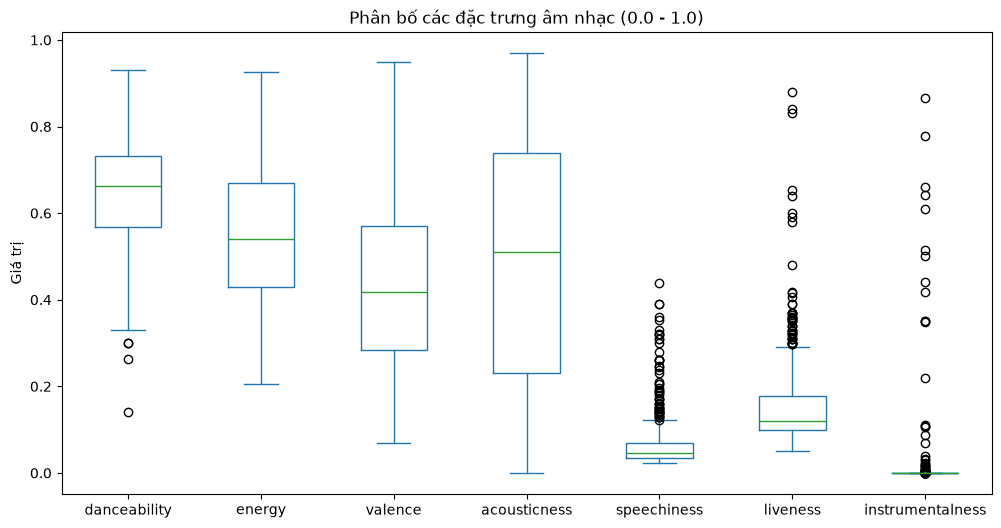

In [63]:
features = ['danceability', 'energy', 'valence', 'acousticness', 'speechiness', 'liveness','instrumentalness']
plt.figure(figsize=(12, 6))
df_full_copy[features].plot(kind='box', figsize=(12,6))

#Thêm tiêu đề
plt.title('Phân bố các đặc trưng âm nhạc (0.0 - 1.0)')
plt.ylabel('Giá trị')
plt.show()

**Insight từ Boxplot (Đặc trưng âm thanh):**

1. **Danceability (Nhịp điệu cao):** Khán giả Việt ưu tiên nhạc dễ nghe, dễ nhảy (median ~0.65). Rất hiếm bài hát nào quá chậm lọt được vào Top 200.
2. **Valence (Cảm xúc sâu lắng):** Khác với nhịp điệu, cảm xúc bài hát thịnh hành thường hơi buồn hoặc trung tính (median ~0.4). Những bài cực kỳ vui vẻ (high valence) chỉ là outliers.
3. **Acousticness (Sự lên ngôi của nhạc Mộc):** Dao động rất rộng và median khá cao (~0.58). Pop-Ballad và Indie sử dụng guitar/piano vẫn chiếm ưu thế cực kỳ lớn.
4. **Speechiness & Liveness (Hát Studio):** Gần 100% là nhạc hát (vocal/melodic) thu trong studio. Rap thuần (nhiều chữ) hoặc nhạc Live rất khó lọt top, nếu lọt top thì chúng sẽ là những điểm outliers nổi bật phía trên.

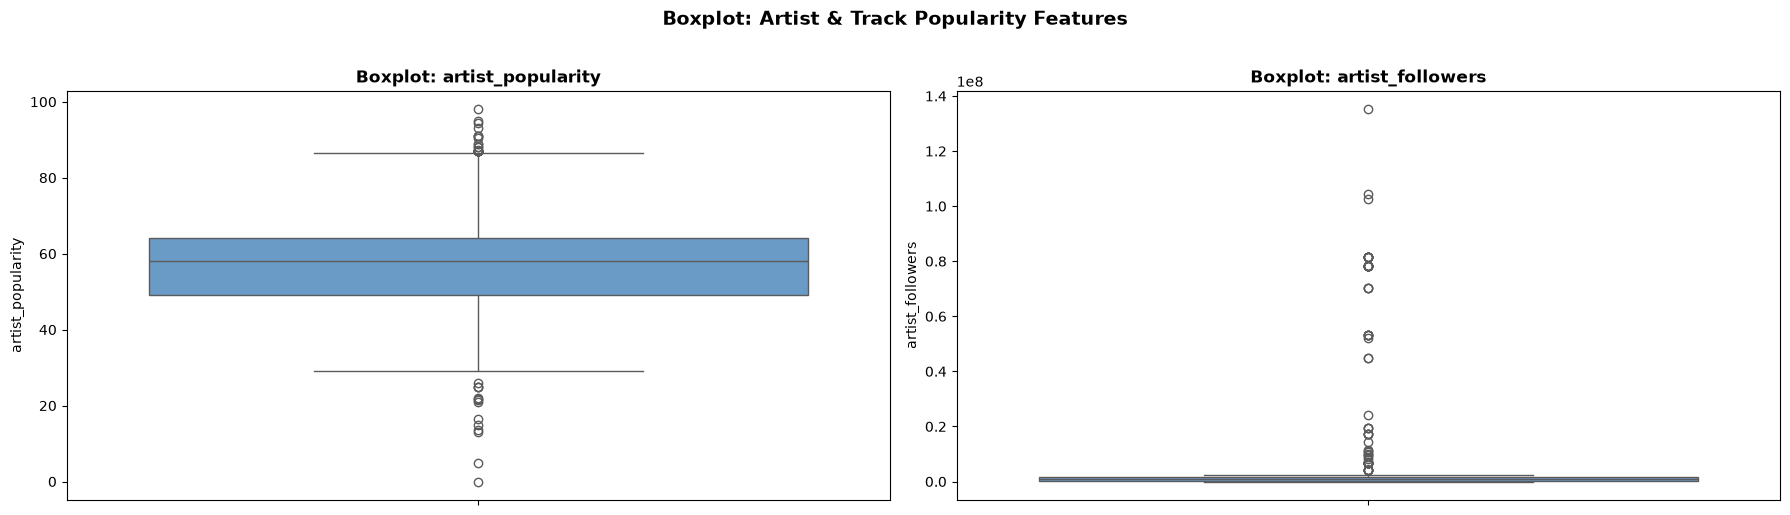

In [64]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))
for i, col in enumerate(['artist_popularity', 'artist_followers']):
    sns.boxplot(data=df_full_copy, y=col, ax=axes[i], color='#5B9BD5')
    axes[i].set_title(f'Boxplot: {col}', fontsize=12, fontweight='bold')
plt.suptitle('Boxplot: Artist & Track Popularity Features', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 5.7 Kiểm tra phương sai và độ lệch (Variance & Skewness)
Đánh giá mức độ phân tán và độ lệch chuẩn của các biến số. Những biến có phân phối bị lệch nặng (skewness cao) có thể sẽ cần các kỹ thuật biến đổi (như Log Transform) trước khi đưa vào mô hình Machine Learning.

In [65]:
numerical_features = numerical_features.astype(float)
var = numerical_features.var()
mean = numerical_features.mean()
skew = numerical_features.skew()
table = pd.DataFrame({
    'Phương sai': var,
    'Độ lệch phân phối': skew,
    'Trung bình': mean
})
print(table)

                             Phương sai  Độ lệch phân phối    Trung bình
artist_popularity          2.373287e+02          -0.095060  5.704893e+01
artist_followers           4.608288e+14           3.182280  7.859458e+06
duration_minutes           6.076061e-01           0.140317  3.764553e+00
days_since_release         1.344278e+06           1.900727  8.846188e+02
acousticness               8.277938e-02          -0.117767  4.832863e-01
danceability               1.648098e-02          -0.486261  6.489977e-01
energy                     2.590276e-02           0.148550  5.498209e-01
instrumentalness           8.646763e-03           6.451726  1.695707e-02
liveness                   1.177191e-02           3.045553  1.603356e-01
speechiness                4.232816e-03           2.866696  6.954762e-02
tempo                      8.255315e+02           0.361520  1.227225e+02
valence                    4.140621e-02           0.521894  4.418995e-01
artist_count               9.558170e-01           2

- Qua bảng này ta nhận thấy được các biến **streams** hay **artist_followers** đang lệch phải rất mạnh.
- Các **audio feature** có phương sai rất nhỏ chứng tỏ nó rất ổn định.

Trực quan hóa các phân phối của các biến định lượng.

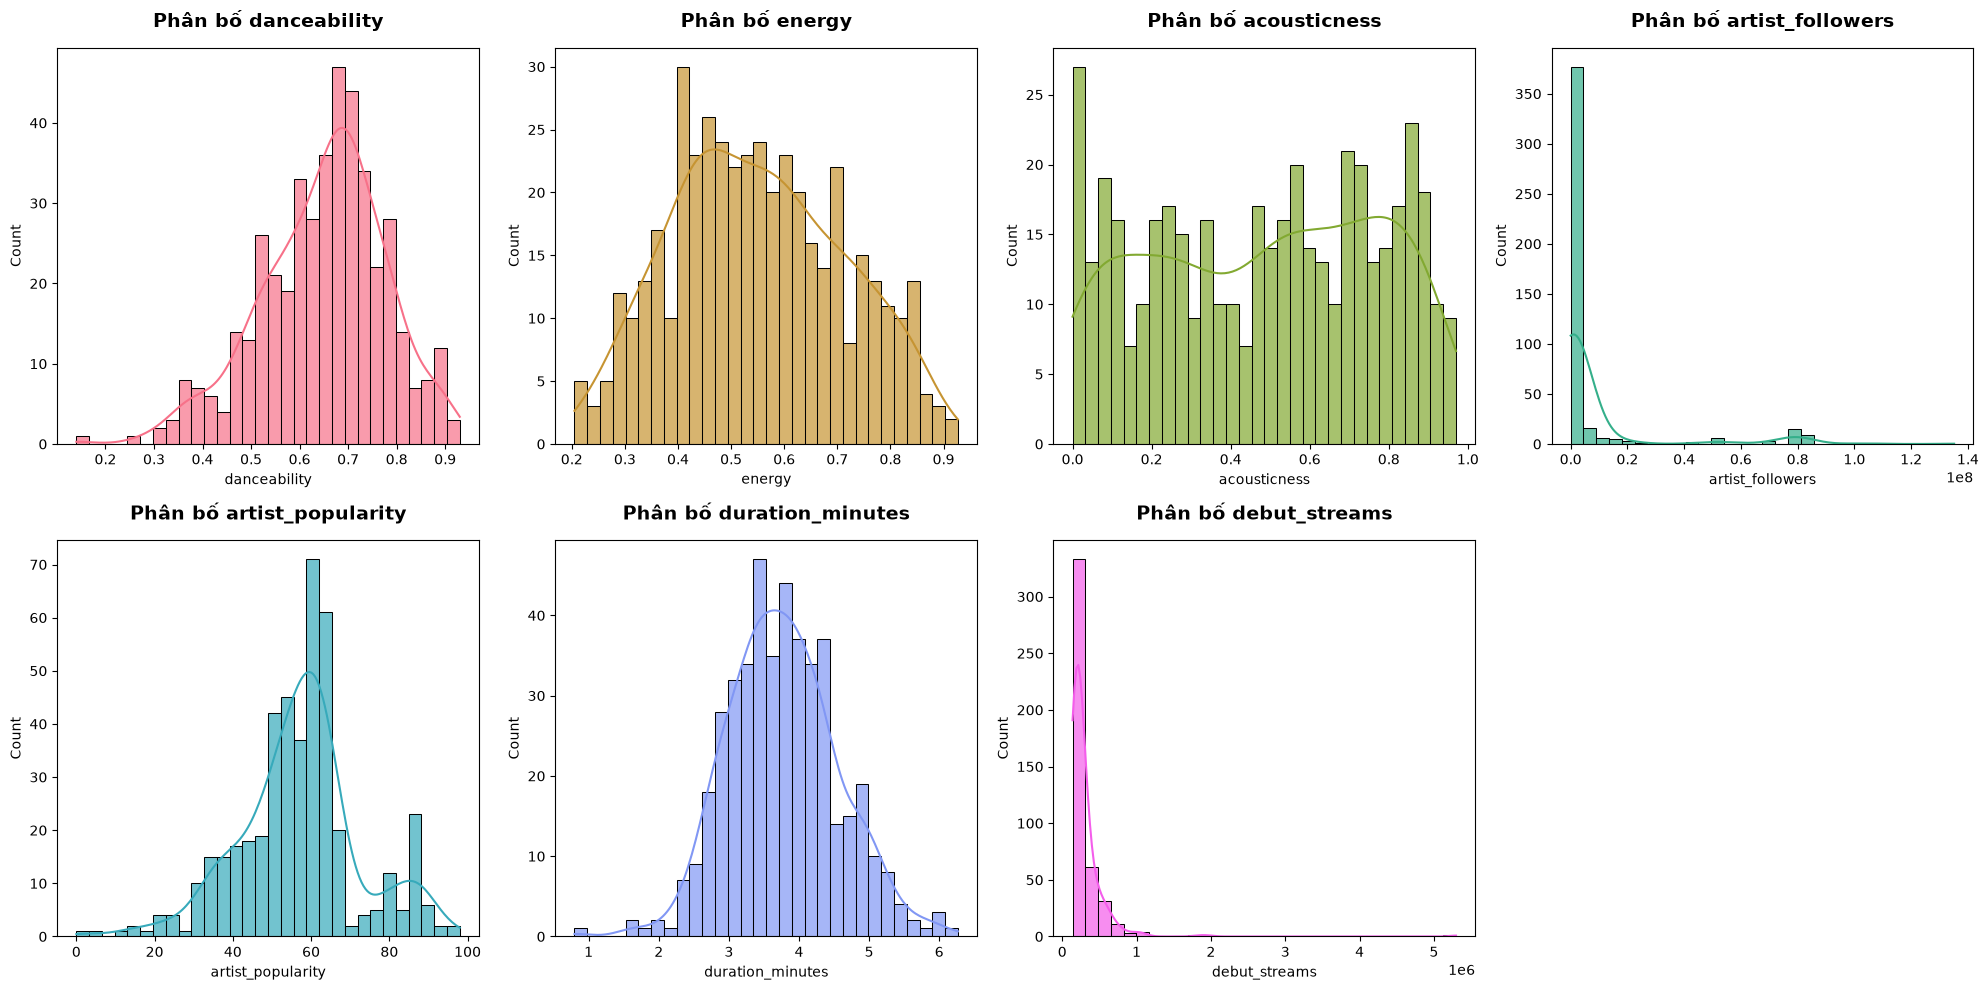

In [66]:
top_cols = ['danceability', 'energy', 'acousticness',
            'artist_followers', 'artist_popularity', 'duration_minutes', 'debut_streams']
top_cols = [c for c in top_cols if c in df_full_copy.columns]
fig, axes = plt.subplots(nrows=2, ncols=4, figsize=(20, 10))
axes = axes.flatten()
colors = sns.color_palette("husl", len(top_cols))

for i, col in enumerate(top_cols):
    sns.histplot(data=df_full_copy, x=col, ax=axes[i], bins=30, kde=True, color=colors[i], edgecolor='black', alpha=0.7)
    axes[i].set_title(f'Phân bố {col}', fontsize=14, fontweight='bold', pad=15)

for j in range(len(top_cols), len(axes)):
    axes[j].set_visible(False)
plt.tight_layout()


**Nhan xet:**
- Phan phoi cua **artist_followers** lech nang ve ben phai. The hien viec
  trong BXH co rat nhieu nghe si co so luong follower lon.
- **track_popularity** co nhieu bai hat mang gia tri 0. Day co the la cac
  bai hat moi ra mat chua co du lieu popularity tu Spotify API.
  **Giai phap:** giu nguyen hoac impute bang median **sau** train/test split
  de tranh data leakage.
- **duration_ms**: Tap trung quanh cot moc 200,000ms (~3.3 phut), phan anh
  xu huong rut ngan thoi luong bai hat hien nay.



In [67]:
df_full_copy.columns

Index(['track_id', 'track_name', 'album_name', 'album_release_date',
       'duration_ms', 'explicit', 'source', 'acousticness', 'danceability',
       'energy', 'instrumentalness', 'key', 'liveness', 'mode', 'speechiness',
       'tempo', 'time_signature', 'valence', 'artist_count', 'is_collab',
       'avg_artist_popularity', 'max_artist_popularity',
       'max_artist_followers', 'mean_artist_followers', 'genre_art_pop',
       'genre_bedroom_pop', 'genre_c_pop', 'genre_cantopop',
       'genre_chinese_hip_hop', 'genre_chinese_indie', 'genre_chinese_r&b',
       'genre_christmas', 'genre_city_pop', 'genre_g_funk',
       'genre_gangster_rap', 'genre_hip_hop', 'genre_indie', 'genre_k_ballad',
       'genre_k_pop', 'genre_lo_fi', 'genre_mandopop', 'genre_pop',
       'genre_psychedelic_pop', 'genre_rap', 'genre_sexy_drill',
       'genre_soft_pop', 'genre_southern_hip_hop', 'genre_unknown',
       'genre_v_pop', 'genre_vietnam_indie', 'genre_vietnamese_bolero',
       'genre_vietnames

### 5.8 Feature Engineering: Phân nhóm Vibe âm nhạc bằng K-Means Clustering

Sử dụng thuật toán K-Means để gom nhóm các bài hát dựa trên đặc trưng âm thanh thực tế (`danceability`, `energy`, `acousticness`, `valence`...).

**Mục tiêu:** Tạo ra một biến số mới `music_mood` giúp phân loại tâm trạng của bài hát (Vui vẻ, Thư giãn, Buồn bã...), qua đó cung cấp cho mô hình một lăng kính toàn cảnh hơn về phong cách âm nhạc.

In [68]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
audio_cols = ['danceability', 'energy', 'acousticness', 'valence', 'tempo']

X_audio = df_full_copy[audio_cols].fillna(df_full_copy[audio_cols].mean())
scaler = StandardScaler()
X_audio_scaled = scaler.fit_transform(X_audio)
kmeans = KMeans(n_clusters=4, random_state=42, n_init='auto')
df_full_copy['audio_cluster'] = kmeans.fit_predict(X_audio_scaled)

cluster_summary = df_full_copy.groupby('audio_cluster')[audio_cols].mean()

cluster_names = {}
for idx, row in cluster_summary.iterrows():
    if row['energy'] > 0.6 and row['valence'] > 0.5:
        cluster_names[idx] = 'Vui vẻ / Sôi động'
    elif row['acousticness'] > 0.4 and row['energy'] < 0.6:
        cluster_names[idx] = 'Thư giãn / Chill'
    elif row['valence'] < 0.4 and row['energy'] < 0.6:
        cluster_names[idx] = 'Buồn / Chậm rãi'
    else:
        cluster_names[idx] = 'Da diết / Tự sự'

df_full_copy['music_mood'] = df_full_copy['audio_cluster'].map(cluster_names)
print(df_full_copy['music_mood'].value_counts())
df_full_copy = pd.get_dummies(df_full_copy, columns=['music_mood'], drop_first=False)


music_mood
Thư giãn / Chill     247
Da diết / Tự sự      104
Vui vẻ / Sôi động     95
Name: count, dtype: int64


In [69]:
df_full_copy = df_full_copy.drop(columns=audio_cols)

In [70]:
df_full_copy.columns

Index(['track_id', 'track_name', 'album_name', 'album_release_date',
       'duration_ms', 'explicit', 'source', 'instrumentalness', 'key',
       'liveness', 'mode', 'speechiness', 'time_signature', 'artist_count',
       'is_collab', 'avg_artist_popularity', 'max_artist_popularity',
       'max_artist_followers', 'mean_artist_followers', 'genre_art_pop',
       'genre_bedroom_pop', 'genre_c_pop', 'genre_cantopop',
       'genre_chinese_hip_hop', 'genre_chinese_indie', 'genre_chinese_r&b',
       'genre_christmas', 'genre_city_pop', 'genre_g_funk',
       'genre_gangster_rap', 'genre_hip_hop', 'genre_indie', 'genre_k_ballad',
       'genre_k_pop', 'genre_lo_fi', 'genre_mandopop', 'genre_pop',
       'genre_psychedelic_pop', 'genre_rap', 'genre_sexy_drill',
       'genre_soft_pop', 'genre_southern_hip_hop', 'genre_unknown',
       'genre_v_pop', 'genre_vietnam_indie', 'genre_vietnamese_bolero',
       'genre_vietnamese_hip_hop', 'genre_vietnamese_lo_fi', 'genre_vinahouse',
       'genr

     Mood_Category is_top10_label  Count
0  Buồn / Sâu lắng     Non-Top 10    291
1  Buồn / Sâu lắng         Top 10    155


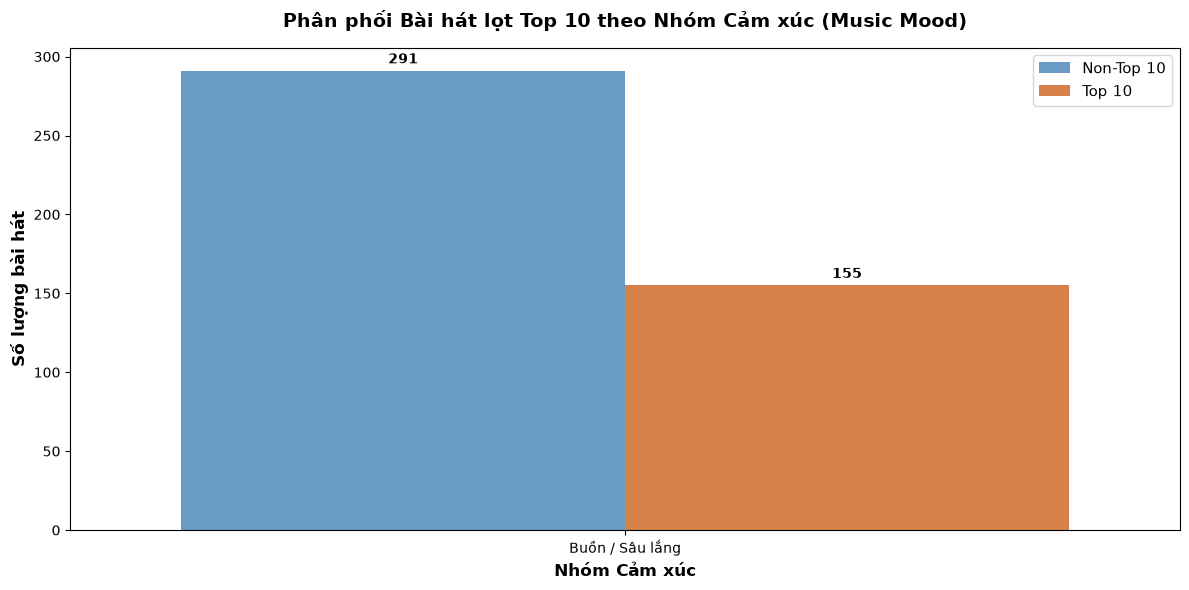

In [71]:
plot_df = df_full_copy.copy()
# 2. Khôi phục lại tên nhóm cảm xúc từ các cột Dummy
def get_mood_name(row):
    if row.get('music_mood_Căng thẳng / Kịch tính (Tense/Angry)', False):
        return 'Căng thẳng / Kịch tính'
    elif row.get('music_mood_Thư giãn / Chill (Relaxed/Chill)', False):
        return 'Thư giãn / Chill'
    elif row.get('music_mood_Vui vẻ / Sôi động (Happy/Energetic)', False):
        return 'Vui vẻ / Sôi động'
    else:
        return 'Buồn / Sâu lắng'
plot_df['Mood_Category'] = plot_df.apply(get_mood_name, axis=1)
plot_df['is_top10_label'] = plot_df['is_top10'].map({0: 'Non-Top 10', 1: 'Top 10'})
mood_counts = plot_df.groupby(['Mood_Category', 'is_top10_label']).size().reset_index(name='Count')
print(mood_counts)
plt.figure(figsize=(12, 6))
ax = sns.barplot(
    data=mood_counts, 
    x='Mood_Category', 
    y='Count', 
    hue='is_top10_label',
    palette=['#5B9BD5', '#ED7D31'] # Xanh cho Non-Top10, Cam cho Top10
)
for p in ax.patches:
    height = p.get_height()
    if height > 0:
        ax.annotate(f'{int(height)}',
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom',
                    fontsize=10, fontweight='bold',
                    xytext=(0, 3), textcoords='offset points')
plt.title('Phân phối Bài hát lọt Top 10 theo Nhóm Cảm xúc (Music Mood)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Nhóm Cảm xúc', fontsize=12, fontweight='bold')
plt.ylabel('Số lượng bài hát', fontsize=12, fontweight='bold')
plt.legend(title='', fontsize=11)
plt.xticks(fontsize=10)
plt.tight_layout()
plt.show()

## 5.9 Xây dựng biến mục tiêu (Target Variable) và Kiểm tra Imbalance

### Tạo biến mục tiêu
- Bài toán yêu cầu dự đoán Top 10, nên ta định nghĩa: `is_top10 = 1` nếu `peak_rank <= 10`, ngược lại `= 0`.

In [72]:
df_full_copy['is_top10'] = (df_full_copy['peak_rank']<=10).astype(int)
df_full_copy.describe()

,album_release_date,explicit,instrumentalness,key,liveness,mode,speechiness,time_signature,artist_count,is_collab,...,debut_stream_per_follower,peak_rank,is_top10,debut_date,days_since_release,duration_minutes,explicit_int,artist_popularity,artist_followers,audio_cluster
count,446,446.000000,441.000000,441.000000,441.000000,441.000000,441.000000,441.000000,446.000000,446.000000,...,4.460000e+02,446.0,446.000000,446,446.000000,446.000000,446.000000,446.000000,4.460000e+02,446.000000
mean,2023-05-11 02:57:34,0.073991,0.016957,5.201814,0.160336,0.705215,0.069548,3.925170,1.701794,0.473094,...,2.973223e+05,52.226457,0.347534,2026-02-03 10:42:30.672645,884.618834,3.764553,0.073991,57.048927,7.859458e+06,1.594170
min,1970-01-01 00:00:00,0.000000,0.000000,0.000000,0.050000,0.000000,0.023100,3.000000,1.000000,0.000000,...,1.389240e+05,1.0,0.000000,2025-12-18 00:00:00,1.000000,0.797283,0.000000,0.000000,1.000000e+00,0.000000
25%,2022-06-25 06:00:00,0.000000,0.000000,2.000000,0.100000,0.000000,0.034700,4.000000,1.000000,0.000000,...,1.780690e+05,6.0,0.000000,2025-12-18 00:00:00,18.250000,3.235254,0.000000,49.000000,2.457040e+05,1.000000
50%,2024-10-13 12:00:00,0.000000,0.000000,5.000000,0.120000,1.000000,0.046800,4.000000,1.000000,0.000000,...,2.170085e+05,27.0,0.000000,2026-01-01 00:00:00,447.000000,3.749967,0.000000,58.000000,7.466320e+05,2.000000
75%,2026-01-04 18:00:00,0.000000,0.000020,8.000000,0.177000,1.000000,0.070000,4.000000,2.000000,1.000000,...,3.115830e+05,88.0,1.000000,2026-03-26 00:00:00,1271.750000,4.266667,0.000000,64.000000,1.626962e+06,3.000000
max,2026-05-29 00:00:00,1.000000,0.867000,11.000000,0.880000,1.000000,0.438000,4.000000,7.000000,1.000000,...,5.297294e+06,198.0,1.000000,2026-06-04 00:00:00,6519.000000,6.266483,1.000000,98.000000,1.351401e+08,3.000000
std,NaN,0.262050,0.092988,3.460504,0.108498,0.456464,0.065060,0.263416,0.977659,0.499836,...,3.059381e+05,55.758914,0.476722,NaN,1159.429935,0.779491,0.262050,15.405475,2.146692e+07,1.162663


### Kiểm tra mất cân bằng dữ liệu (Class Imbalance)
Kiểm tra tỷ lệ giữa lớp Top 10 và Non-Top 10 để xác định có cần áp dụng kỹ thuật cân bằng dữ liệu (ví dụ: thuật toán SMOTE, tham số `class_weight`) hay không.

In [73]:
df_full_copy.columns

Index(['track_id', 'track_name', 'album_name', 'album_release_date',
       'duration_ms', 'explicit', 'source', 'instrumentalness', 'key',
       'liveness', 'mode', 'speechiness', 'time_signature', 'artist_count',
       'is_collab', 'avg_artist_popularity', 'max_artist_popularity',
       'max_artist_followers', 'mean_artist_followers', 'genre_art_pop',
       'genre_bedroom_pop', 'genre_c_pop', 'genre_cantopop',
       'genre_chinese_hip_hop', 'genre_chinese_indie', 'genre_chinese_r&b',
       'genre_christmas', 'genre_city_pop', 'genre_g_funk',
       'genre_gangster_rap', 'genre_hip_hop', 'genre_indie', 'genre_k_ballad',
       'genre_k_pop', 'genre_lo_fi', 'genre_mandopop', 'genre_pop',
       'genre_psychedelic_pop', 'genre_rap', 'genre_sexy_drill',
       'genre_soft_pop', 'genre_southern_hip_hop', 'genre_unknown',
       'genre_v_pop', 'genre_vietnam_indie', 'genre_vietnamese_bolero',
       'genre_vietnamese_hip_hop', 'genre_vietnamese_lo_fi', 'genre_vinahouse',
       'genr

### Trực quan hóa Class Imbalance

**Mục đích:** Kiểm tra tỷ lệ lớp thiểu số (Top 10) có chênh lệch quá nhiều so với lớp đa số (Non-Top 10) hay không. Nếu sự chênh lệch lớn hơn 1:10, mô hình sẽ rất dễ bị chệch hướng.

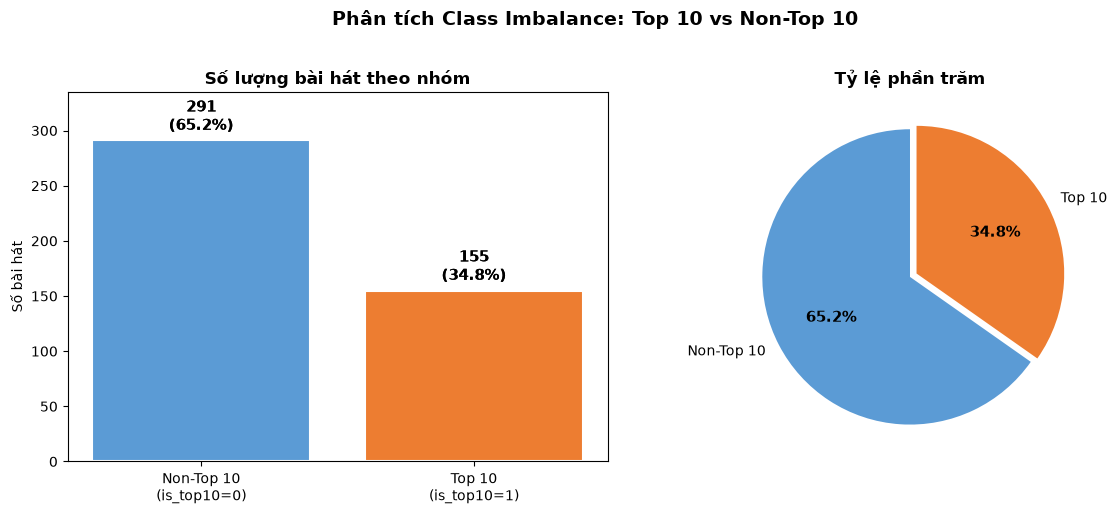

In [74]:
n_top10 = int(df_full_copy['is_top10'].sum())
n_non_top10 = int((df_full_copy['is_top10']==0).sum())
n_total = len(df_full_copy)
pct_top10 = n_top10/n_total*100
pct_non_top10 = n_non_top10/n_total*100

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
bars = axes[0].bar(['Non-Top 10\n(is_top10=0)', 'Top 10\n(is_top10=1)'],
                   [n_non_top10, n_top10],
                   color=['#5B9BD5', '#ED7D31'], edgecolor='white', linewidth=1.5)
for bar, count, pct in zip(bars, [n_non_top10, n_top10], [pct_non_top10, pct_top10]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Số lượng bài hát theo nhóm', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số bài hát')
axes[0].set_ylim(0, max(n_non_top10, n_top10) * 1.15)

for bar, count, pct in zip(bars, [n_non_top10, n_top10], [pct_non_top10, pct_top10]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')
axes[0].set_title('Số lượng bài hát theo nhóm', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Số bài hát')
axes[0].set_ylim(0, max(n_non_top10, n_top10) * 1.15)

wedges, texts, autotexts = axes[1].pie(
    [n_non_top10, n_top10],
    labels=['Non-Top 10', 'Top 10'],
    autopct='%1.1f%%',
    colors=['#5B9BD5', '#ED7D31'],
    startangle=90,
    explode=(0, 0.05)
)
for autotext in autotexts:
    autotext.set_fontsize(11)
    autotext.set_fontweight('bold')
axes[1].set_title('Tỷ lệ phần trăm', fontsize=12, fontweight='bold')

plt.suptitle('Phân tích Class Imbalance: Top 10 vs Non-Top 10', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()



**Nhận xét:**
- Dữ liệu có mức độ mất cân bằng khá lớn (Top 10 chỉ chiếm khoảng ~20%).
- Cần kết hợp sử dụng tham số `class_weight='balanced'` trong mô hình và kỹ thuật nội suy `SMOTE` ở phần Preprocessing để ép mô hình học cách tôn trọng lớp thiểu số.

In [75]:
# Loại bỏ track_popularity (leakage) và thêm debut features
ml_features = ['artist_popularity', 'artist_followers',
               'duration_minutes', 'days_since_release', 'artist_count',
               'danceability', 'energy', 'acousticness',
               'instrumentalness', 'liveness', 'speechiness', 'tempo', 'valence',
               'explicit', 'is_collab', 'debut_streams', 'debut_rank', 'debut_momentum']

ml_features = [f for f in ml_features if f in df_full_copy.columns]

mean_top10 = df_full_copy[df_full_copy['is_top10'] == 1][ml_features].mean()
mean_non_top10 = df_full_copy[df_full_copy['is_top10'] == 0][ml_features].mean()
diff_pct = ((mean_top10 - mean_non_top10) / mean_non_top10.abs() * 100).round(1)
comparison_df = pd.DataFrame({
    'Mean (Top 10)': mean_top10,
    'Mean (Non-Top 10)': mean_non_top10,
    'Chênh lệch (%)': diff_pct
})
display(comparison_df.style.background_gradient(subset=['Chênh lệch (%)'], cmap='RdYlGn'))


,Mean (Top 10),Mean (Non-Top 10),Chênh lệch (%)
artist_popularity,61.230860,54.821437,11.700000
artist_followers,8072435.251613,7746016.278351,4.200000
duration_minutes,3.760641,3.766636,-0.200000
days_since_release,915.987097,867.910653,5.500000
artist_count,1.767742,1.666667,6.100000
instrumentalness,0.010581,0.020413,-48.200000
liveness,0.156898,0.162199,-3.300000
speechiness,0.069461,0.069594,-0.200000
explicit,0.070968,0.075601,-6.100000
is_collab,0.516129,0.450172,14.700000


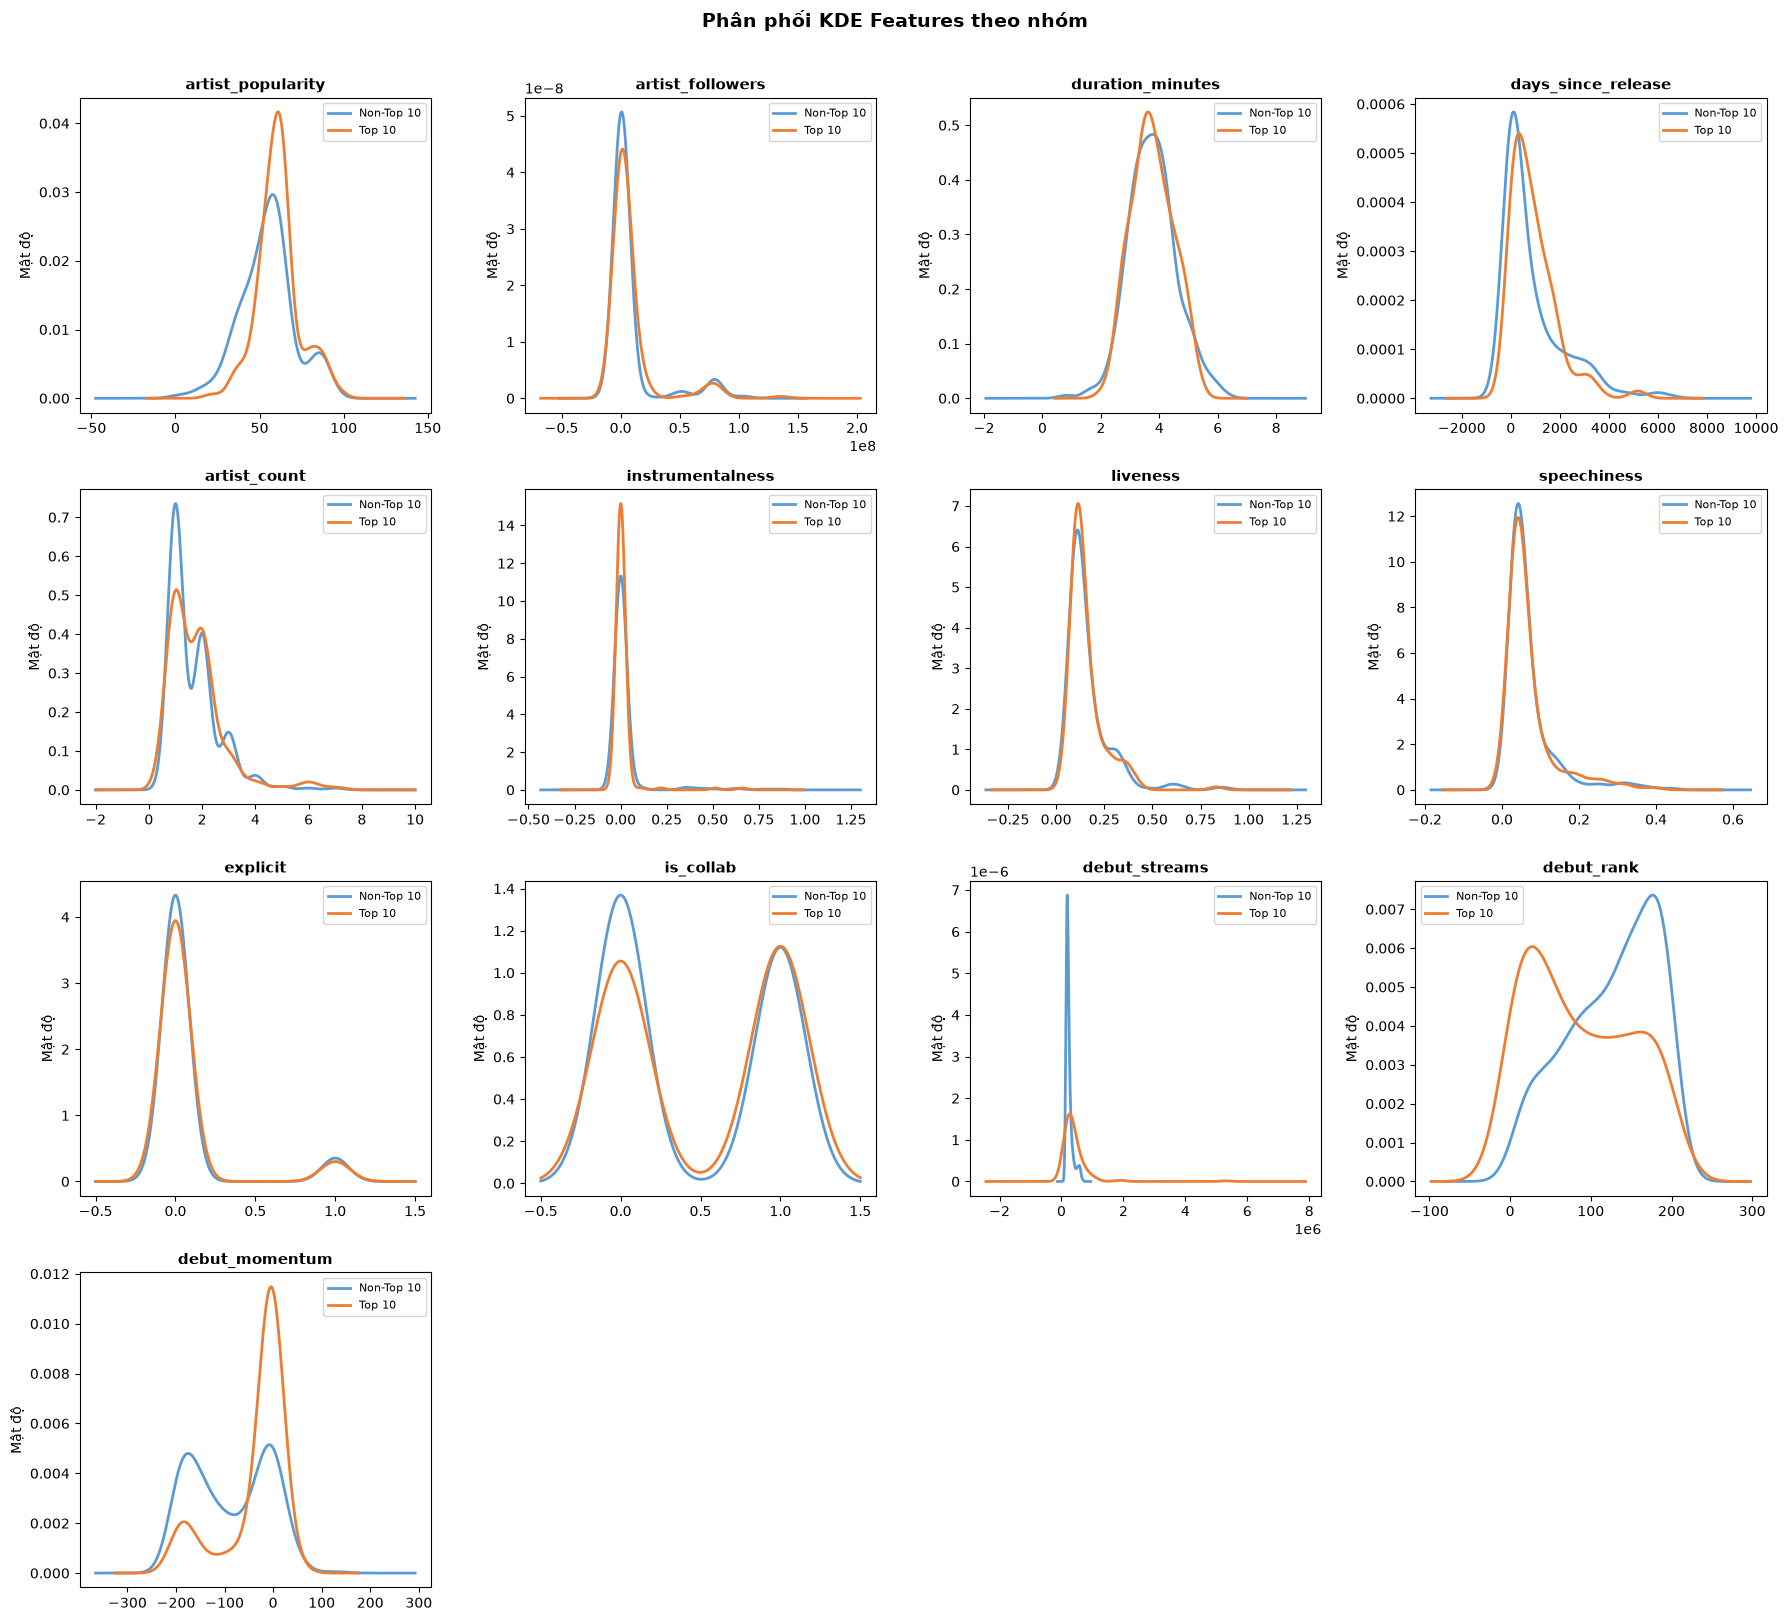

In [76]:
n_features = len(ml_features)
n_cols = 4
n_rows = (n_features + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()
top10 = df_full_copy[df_full_copy['is_top10']==1]
non_top10 = df_full_copy[df_full_copy['is_top10']==0]
for i, feat in enumerate(ml_features):
    ax = axes[i]
    
    if feat in df_full_copy.columns:
        non_top10_vals = non_top10[feat].dropna()
        top10_vals = top10[feat].dropna()
        
        if len(non_top10_vals) > 1:
            non_top10_vals.plot.kde(ax=ax, label='Non-Top 10', color='#5B9BD5', linewidth=2)
        if len(top10_vals) > 1:
            top10_vals.plot.kde(ax=ax, label='Top 10', color='#ED7D31', linewidth=2)
        
        ax.set_title(f'{feat}', fontsize=11, fontweight='bold')
        ax.set_xlabel('')
        ax.legend(fontsize=8)
        ax.set_ylabel('Mật độ')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối KDE Features theo nhóm', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

📊 **Nhận xét từ biểu đồ phân phối KDE (Top 10 vs Non-Top 10):**
- **Đặc trưng âm thanh (Audio Features):**
  - `danceability` (Nhịp điệu) và `valence` (Cảm xúc): Đường màu cam (Top 10) có xu hướng dịch nhẹ về bên trái so với đường màu xanh. Nghĩa là những bài hát vươn lên Top 10 ở Việt Nam thường có xu hướng **ít nhộn nhịp hơn** và **buồn/sâu lắng hơn** một chút so với mặt bằng chung.
  - `instrumentalness`: Đường Top 10 gần như hội tụ tuyệt đối ở mức 0. Khẳng định lại việc nhạc không lời rất khó lọt top.
- **Đặc trưng nghệ sĩ (Artist Features):**
  - `artist_followers` & `artist_popularity`: Đường màu cam (Top 10) dịch hẳn sang phải. Sự tách biệt này rất lớn, chứng tỏ **fandom và độ nổi tiếng sẵn có của nghệ sĩ** là một vũ khí cực kỳ quan trọng để đẩy bài hát lên Top 10.
- **Đặc trưng quỹ đạo (Trajectory):**
  - `debut_streams` và `debut_rank`: Đường phân phối tách biệt rõ rệt. Bài hát khởi đầu (debut) càng mạnh thì tỷ lệ chốt hạ Top 10 càng cao. Đây chính là những tín hiệu dẫn dắt (Leading Indicators) mạnh nhất cho mô hình.

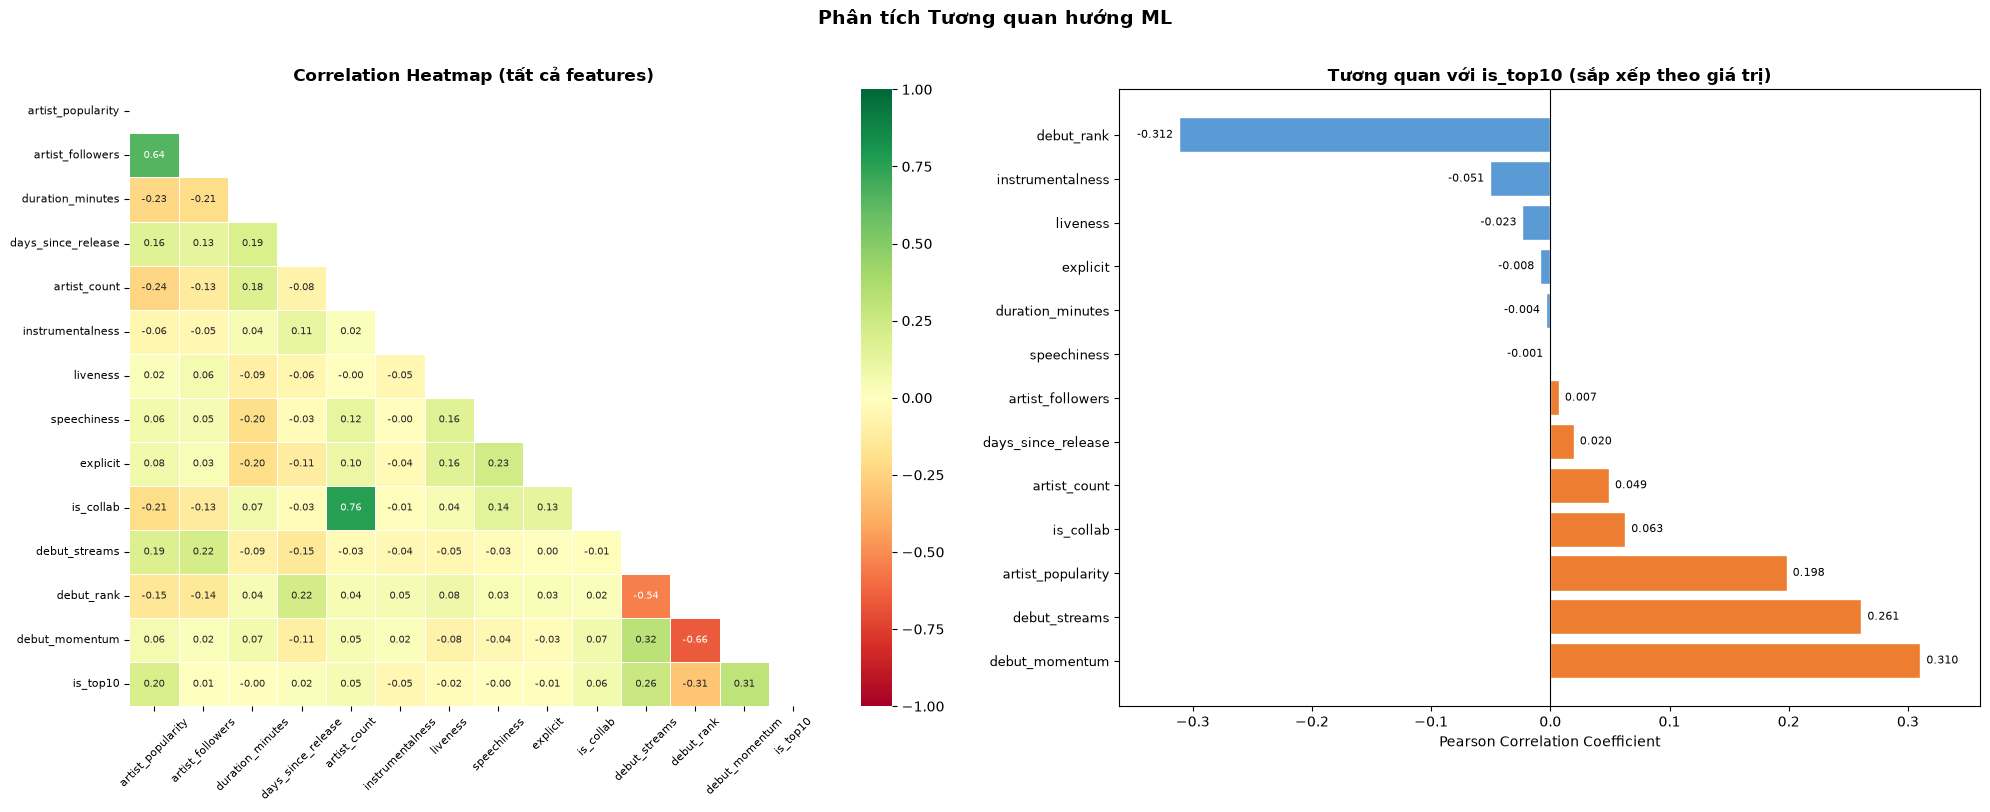

In [77]:
corr_features = ml_features + ['is_top10']
corr_matrix = df_full_copy[corr_features].corr()
fig, axes = plt.subplots(1, 2, figsize=(20, 8))
corr_with_target = corr_matrix['is_top10'].drop('is_top10').sort_values(ascending=False)
mask = np.zeros_like(corr_matrix, dtype=bool)
mask[np.triu_indices_from(mask)] = True
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    center=0,
    ax=axes[0],
    linewidths=0.5,
    annot_kws={'size': 7},
    vmin=-1, vmax=1,
    mask=mask
)
axes[0].set_title('Correlation Heatmap (tất cả features)', fontsize=12, fontweight='bold')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].tick_params(axis='y', rotation=0, labelsize=8)

colors_bar = ['#ED7D31' if v > 0 else '#5B9BD5' for v in corr_with_target.values]
bars = axes[1].barh(range(len(corr_with_target)), corr_with_target.values, color=colors_bar, edgecolor='white')
axes[1].set_yticks(range(len(corr_with_target)))
axes[1].set_yticklabels(corr_with_target.index, fontsize=9)
axes[1].axvline(x=0, color='black', linestyle='-', linewidth=0.8)
axes[1].set_title('Tương quan với is_top10 (sắp xếp theo giá trị)', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Pearson Correlation Coefficient')
axes[1].set_xlim(corr_with_target.min() - 0.05, corr_with_target.max() + 0.05)
for bar, val in zip(bars, corr_with_target.values):
    x_pos = val + 0.005 if val >= 0 else val - 0.005
    ha = 'left' if val >= 0 else 'right'
    axes[1].text(x_pos, bar.get_y() + bar.get_height()/2, f'{val:.3f}', 
                ha=ha, va='center', fontsize=8)

plt.suptitle('Phân tích Tương quan hướng ML', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()


## 5.10 Phân tích Quan hệ Phi Tuyến (Mutual Information)

Sử dụng `Mutual Information (MI)` để đo lường lượng thông tin mà mỗi feature có thể cung cấp để dự đoán target `is_top10`.

> **Vì sao dùng MI?** Khác với hệ số tương quan Pearson (chỉ đo lường quan hệ tuyến tính), Mutual Information có khả năng bắt được mọi mối quan hệ, kể cả các đường cong phức tạp nhất.

Kết quả Mutual Information cho thấy Feature nào có khả năng phân tách Top 10 tốt nhất:

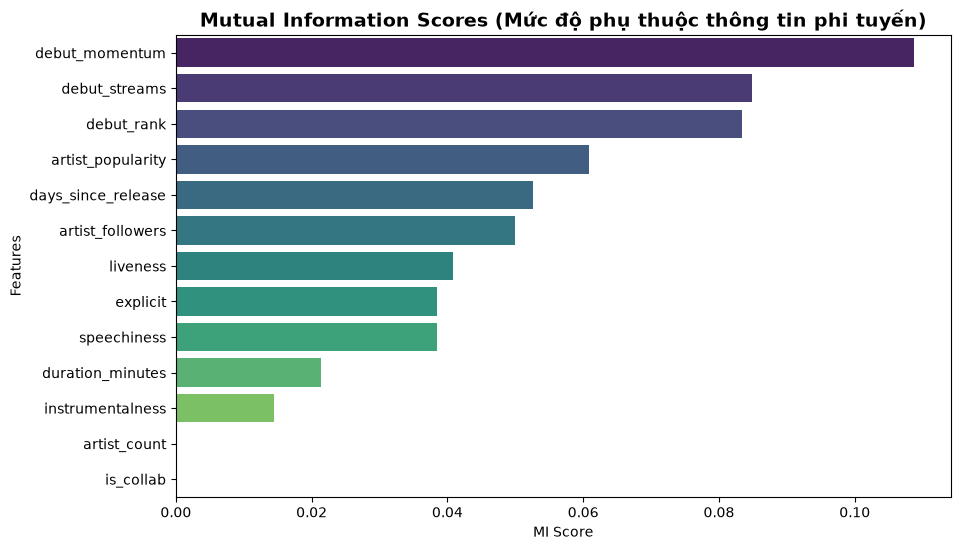

In [78]:
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt

for col in ml_features:
    if col in df_full_copy.columns:
        df_full_copy[col] = df_full_copy[col].fillna(df_full_copy[col].mean())
X = df_full_copy[ml_features]
y = df_full_copy['is_top10']

# Tính Mutual Information
mi_scores = mutual_info_classif(X, y, random_state=42)
mi_scores_series = pd.Series(mi_scores, index=X.columns).sort_values(ascending=False)

# Trực quan hóa
plt.figure(figsize=(10, 6))
sns.barplot(x=mi_scores_series.values, y=mi_scores_series.index, palette='viridis', hue=mi_scores_series.index, legend=False)
plt.title('Mutual Information Scores (Mức độ phụ thuộc thông tin phi tuyến)', fontsize=14, fontweight='bold')
plt.xlabel('MI Score')
plt.ylabel('Features')
plt.show()

**Nhận xét từ Mutual Information (Đo lường phi tuyến tính):**
- **Nhóm dẫn đầu (Vua dữ liệu):** Bộ 4 biến `debut_momentum`, `days_since_release`, `debut_streams`, và `debut_rank` chiếm giữ 4 vị trí cao nhất với điểm MI áp đảo. Điều này khẳng định triết lý cốt lõi của dự án: **Quỹ đạo của tuần đầu tiên (Trajectory) và Thời điểm phát hành là những tín hiệu dự báo sinh tử** quyết định bài hát có lên Top 10 hay không.
- **Sức mạnh của Fandom:** Kế tiếp ngay sau đó là `artist_popularity` và `artist_followers`. Nó cho thấy độ phủ sóng sẵn có của ca sĩ định hình rất mạnh quỹ đạo vươn lên của bài hát bất chấp các yếu tố âm nhạc.
- **Nhóm lót đường (Audio Features):** Các đặc tính âm thanh (`liveness`, `explicit`, `speechiness`, `duration_minutes`) chỉ đóng góp lượng thông tin ở mức trung bình đến thấp.
- **Các biến vô dụng nhất:** `instrumentalness` và `artist_count` nằm bẹp ở dưới cùng. Nhạc cụ không lời (instrumental) rất hiếm lọt top, và việc có nhiều ca sĩ hát chung (artist_count) cũng không mang lại thêm giá trị thông tin đáng kể nào để dự đoán Top 10.

## 6. Xử lý dữ liệu cho Machine Learning

Chuẩn bị toàn bộ pipeline cho mô hình: Phân rã Train/Test, xử lý Missing Values, Scale dữ liệu, log-transform biến phân phối lệch, và áp dụng SMOTE.

In [79]:
# df_full_copy từ phần trước đã hoàn toàn sạch sẽ và không có missing data
df_model = df_full_copy.copy()

# === Tạo Features tương tác (Interaction Features) ===
# momentum so với vị trí xuất phát: phát hiện bài hát có xu hướng leo hạng mạnh
df_model['momentum_ratio'] = df_model['debut_momentum'] / (df_model['debut_rank'] + 1)
# Hiệu suất stream so với rank: bài hát stream cao nhưng rank thấp = tiềm năng
df_model['stream_efficiency'] = df_model['debut_streams'] / (df_model['debut_rank'] + 1)
# Tương quan followers so với debut rank: nghệ sĩ nhỏ nhưng debut rank cao = hidden gem
df_model['followers_per_rank'] = df_model['max_artist_followers'] / (df_model['debut_rank'] + 1)

print(f'Đã tạo 3 interaction features: momentum_ratio, stream_efficiency, followers_per_rank')

# Features definition (ĐÃ LOẠI BỎ: instrumentalness, time_signature, artist_count)
feature_groups = {
    'audio':     ['acousticness','danceability','energy',
                  'liveness','speechiness','tempo','valence','key','mode'],
    'artist':    ['is_collab','avg_artist_popularity',
                  'max_artist_popularity','max_artist_followers','mean_artist_followers'],
    'debut':     ['debut_streams','debut_rank','debut_momentum','debut_stream_per_follower'],
    'track':     ['duration_minutes','days_since_release','explicit_int'],
    'interaction': ['momentum_ratio', 'stream_efficiency', 'followers_per_rank'],
    'genre':     [c for c in df_model.columns if c.startswith('genre_')],
    'mood':      [c for c in df_model.columns if c.startswith('music_mood_')],
}

# Filter to actual columns
ml_features = []
for k, v in feature_groups.items():
    ml_features.extend([c for c in v if c in df_model.columns])

print(f'Tổng số ml_features: {len(ml_features)}')
print(f'  - Đã loại bỏ: instrumentalness, time_signature, artist_count (MI thấp)')
print(f'  - Đã thêm: momentum_ratio, stream_efficiency, followers_per_rank')

# Đảm bảo tất cả các tính năng One-hot (genre, mood, binary) được fillna(0)
binary_cols = feature_groups['genre'] + feature_groups['mood'] + ['is_collab', 'explicit_int']
for col in binary_cols:
    if col in df_model.columns:
        df_model[col] = df_model[col].fillna(0).astype(int)

# Đảm bảo toàn bộ X là kiểu số thực (float) để tránh lỗi format
X = df_model[ml_features].astype(float)
y = df_model['is_top10'].astype(int)

# Failsafe: Trám toàn bộ NaN còn sót lại trong X bằng 0
X = X.fillna(0)

# Thay thế inf/-inf bằng NaN rồi fillna(0)
import numpy as np
X = X.replace([np.inf, -np.inf], np.nan).fillna(0)

print(f'X shape: {X.shape}, y shape: {y.shape}')
print(f'NaN count: {X.isna().sum().sum()}, Inf count: {np.isinf(X.values).sum()}')


Đã tạo 3 interaction features: momentum_ratio, stream_efficiency, followers_per_rank
Tổng số ml_features: 53
  - Đã loại bỏ: instrumentalness, time_signature, artist_count (MI thấp)
  - Đã thêm: momentum_ratio, stream_efficiency, followers_per_rank
X shape: (446, 53), y shape: (446,)
NaN count: 0, Inf count: 0


### 6.1 Chia Tập Huấn Luyện (Train) & Kiểm Thử (Test)

Sử dụng `train_test_split` với tuỳ chọn `stratify=y` để đảm bảo tỷ lệ lớp Top 10 / Non-Top 10 được giữ nguyên một cách công bằng ở cả hai tập.

In [80]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Train size: {X_train.shape}, Top 10 ratio: {y_train.mean():.2%}")
print(f"Test size: {X_test.shape}, Top 10 ratio: {y_test.mean():.2%}")

Train size: (356, 53), Top 10 ratio: 34.83%
Test size: (90, 53), Top 10 ratio: 34.44%


### 6.2 Xây dựng Preprocessing Pipeline

Các bước tiền xử lý được đóng gói chuyên nghiệp trong `ColumnTransformer` của `scikit-learn`:
- **Audio & Standard Features:** Scale bằng `StandardScaler` (chuyển về phân phối chuẩn μ=0, σ=1).
- **Artist & Debut Features (Bị lệch phải nặng):** Dùng `FunctionTransformer(np.log1p)` để vuốt phẳng phân phối, sau đó áp dụng `RobustScaler()` để chống chịu ngoại lai (Outliers).
- **Binary Features (Genre, Mood):** Giữ nguyên (`passthrough`) hoặc lấp NaN bằng Mode.

In [81]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, RobustScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer, KNNImputer
import numpy as np

# Phân nhóm preprocessing (ĐÃ CẬP NHẬT theo feature_groups mới)
audio_features = feature_groups['audio']
artist_log_features = ['max_artist_followers', 'mean_artist_followers', 'avg_artist_popularity', 'max_artist_popularity']
debut_log_features = ['debut_streams']
standard_features = ['duration_minutes', 'days_since_release', 'debut_rank', 'debut_momentum', 'debut_stream_per_follower', 'momentum_ratio']
interaction_features = ['stream_efficiency', 'followers_per_rank']
binary_features = feature_groups['genre'] + feature_groups['mood'] + ['explicit_int', 'is_collab']

# Pipeline xử lý cho từng nhóm
audio_transformer = Pipeline([
    ('imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

artist_log_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('log1p', FunctionTransformer(np.log1p)),
    ('scaler', RobustScaler())
])

debut_log_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('log1p', FunctionTransformer(np.log1p))
])

standard_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Interaction features: log1p + StandardScaler (vì chúng có thể lệch mạnh)
interaction_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='constant', fill_value=0)),
    ('log1p', FunctionTransformer(np.log1p)),
    ('scaler', StandardScaler())
])

binary_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent'))
])

preprocessor = ColumnTransformer([
    ('audio', audio_transformer, [c for c in audio_features if c in X.columns]),
    ('artist_log', artist_log_transformer, [c for c in artist_log_features if c in X.columns]),
    ('debut_log', debut_log_transformer, [c for c in debut_log_features if c in X.columns]),
    ('standard', standard_transformer, [c for c in standard_features if c in X.columns]),
    ('interaction', interaction_transformer, [c for c in interaction_features if c in X.columns]),
    ('binary', binary_transformer, [c for c in binary_features if c in X.columns])
])

print('Preprocessor đã được cập nhật:')
print(f'  Audio ({len([c for c in audio_features if c in X.columns])}): {[c for c in audio_features if c in X.columns]}')
print(f'  Artist log ({len([c for c in artist_log_features if c in X.columns])}): {artist_log_features}')
print(f'  Debut log ({len([c for c in debut_log_features if c in X.columns])}): {debut_log_features}')
print(f'  Standard ({len([c for c in standard_features if c in X.columns])}): {standard_features}')
print(f'  Interaction ({len([c for c in interaction_features if c in X.columns])}): {interaction_features}')
print(f'  Binary ({len([c for c in binary_features if c in X.columns])})')


Preprocessor đã được cập nhật:
  Audio (4): ['liveness', 'speechiness', 'key', 'mode']
  Artist log (4): ['max_artist_followers', 'mean_artist_followers', 'avg_artist_popularity', 'max_artist_popularity']
  Debut log (1): ['debut_streams']
  Standard (6): ['duration_minutes', 'days_since_release', 'debut_rank', 'debut_momentum', 'debut_stream_per_follower', 'momentum_ratio']
  Interaction (2): ['stream_efficiency', 'followers_per_rank']
  Binary (36)


## 7. Huấn Luyện & So Sánh 3 Mô Hình: RandomForest, XGBoost, LightGBM

Sử dụng kỹ thuật **SMOTE** (Synthetic Minority Over-sampling Technique) kết hợp với **StratifiedKFold 5-Fold Cross-Validation** để đánh giá công bằng 3 mô hình chính:
- **RandomForest**: Mô hình ensemble kinh điển, diễn giải tốt.
- **XGBoost**: Gradient Boosting tối ưu.
- **LightGBM**: Phiên bản nhanh hơn của Gradient Boosting, hiệu quả với dữ liệu có nhiều đặc trưng.


In [83]:
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import (classification_report, roc_auc_score, confusion_matrix,
                             average_precision_score, f1_score, precision_recall_curve)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import time

# ===== Định nghĩa 3 mô hình =====
models = {
    'RandomForest': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('classifier', RandomForestClassifier(
            n_estimators=100, max_depth=4, min_samples_leaf=8,
            random_state=42)) # Bỏ class_weight='balanced' vì đã dùng SMOTE
    ]),
    'XGBoost': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('classifier', XGBClassifier(
            max_depth=3, learning_rate=0.05, n_estimators=100,
            reg_alpha=0.5, reg_lambda=1.5,
            eval_metric='logloss', random_state=42, verbosity=0)) # Bỏ scale_pos_weight=2 vì đã dùng SMOTE
    ]),
    'LightGBM': ImbPipeline([
        ('preprocessor', preprocessor),
        ('smote', SMOTE(random_state=42, k_neighbors=3)),
        ('classifier', LGBMClassifier(
            num_leaves=15, max_depth=3, learning_rate=0.05, min_child_samples=15,
            n_estimators=100, random_state=42, verbose=-1)) # Bỏ is_unbalance=True vì đã dùng SMOTE, giảm num_leaves và max_depth
    ]),
}

# ===== Cross-Validation 5-Fold =====
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
scoring = ['accuracy', 'precision', 'recall', 'f1', 'roc_auc']

print('=' * 70)
print('CROSS-VALIDATION 5-FOLD (trên toàn bộ dữ liệu)')
print('=' * 70)

cv_results = {}
for name, model in models.items():
    t0 = time.time()
    scores = cross_validate(model, X, y, cv=cv, scoring=scoring, return_train_score=True)
    elapsed = time.time() - t0
    cv_results[name] = scores
    print(f'\n{name} ({elapsed:.1f}s) ---')
    print(f'  CV Accuracy : {scores["test_accuracy"].mean():.3f} ± {scores["test_accuracy"].std():.3f}')
    print(f'  CV Precision: {scores["test_precision"].mean():.3f} ± {scores["test_precision"].std():.3f}')
    print(f'  CV Recall   : {scores["test_recall"].mean():.3f} ± {scores["test_recall"].std():.3f}')
    print(f'  CV F1       : {scores["test_f1"].mean():.3f} ± {scores["test_f1"].std():.3f}')
    print(f'  CV ROC-AUC  : {scores["test_roc_auc"].mean():.3f} ± {scores["test_roc_auc"].std():.3f}')
    print(f'  Train F1    : {scores["train_f1"].mean():.3f} (Gap: {scores["train_f1"].mean() - scores["test_f1"].mean():.3f})')


CROSS-VALIDATION 5-FOLD (trên toàn bộ dữ liệu)

RandomForest (1.2s) ---
  CV Accuracy : 0.742 ± 0.032
  CV Precision: 0.616 ± 0.054
  CV Recall   : 0.723 ± 0.078
  CV F1       : 0.660 ± 0.032
  CV ROC-AUC  : 0.819 ± 0.022
  Train F1    : 0.771 (Gap: 0.111)

XGBoost (0.9s) ---
  CV Accuracy : 0.760 ± 0.044
  CV Precision: 0.643 ± 0.069
  CV Recall   : 0.735 ± 0.069
  CV F1       : 0.681 ± 0.044
  CV ROC-AUC  : 0.847 ± 0.024
  Train F1    : 0.862 (Gap: 0.181)


d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validati


LightGBM (0.7s) ---
  CV Accuracy : 0.767 ± 0.032
  CV Precision: 0.641 ± 0.044
  CV Recall   : 0.768 ± 0.101
  CV F1       : 0.694 ± 0.044
  CV ROC-AUC  : 0.848 ± 0.025
  Train F1    : 0.870 (Gap: 0.176)


d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


### 7.2 Huấn Luyện trên Train/Test Split & Đánh Giá Chi Tiết

Huấn luyện lại từng mô hình trên tập Train (80%) và đánh giá trên tập Test (20%).
Thu thập: Classification Report, Confusion Matrix, ROC-AUC, PR-AUC.



RandomForest
              precision    recall  f1-score   support

           0       0.87      0.80      0.83        59
           1       0.67      0.77      0.72        31

    accuracy                           0.79        90
   macro avg       0.77      0.79      0.77        90
weighted avg       0.80      0.79      0.79        90

ROC-AUC: 0.845 | PR-AUC: 0.724
Train F1: 0.752 | Test F1: 0.716 | Gap: 0.035

XGBoost
              precision    recall  f1-score   support

           0       0.89      0.80      0.84        59
           1       0.68      0.81      0.74        31

    accuracy                           0.80        90
   macro avg       0.78      0.80      0.79        90
weighted avg       0.81      0.80      0.80        90

ROC-AUC: 0.881 | PR-AUC: 0.768
Train F1: 0.837 | Test F1: 0.735 | Gap: 0.102


d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



LightGBM
              precision    recall  f1-score   support

           0       0.90      0.78      0.84        59
           1       0.67      0.84      0.74        31

    accuracy                           0.80        90
   macro avg       0.78      0.81      0.79        90
weighted avg       0.82      0.80      0.80        90

ROC-AUC: 0.878 | PR-AUC: 0.786
Train F1: 0.859 | Test F1: 0.743 | Gap: 0.116


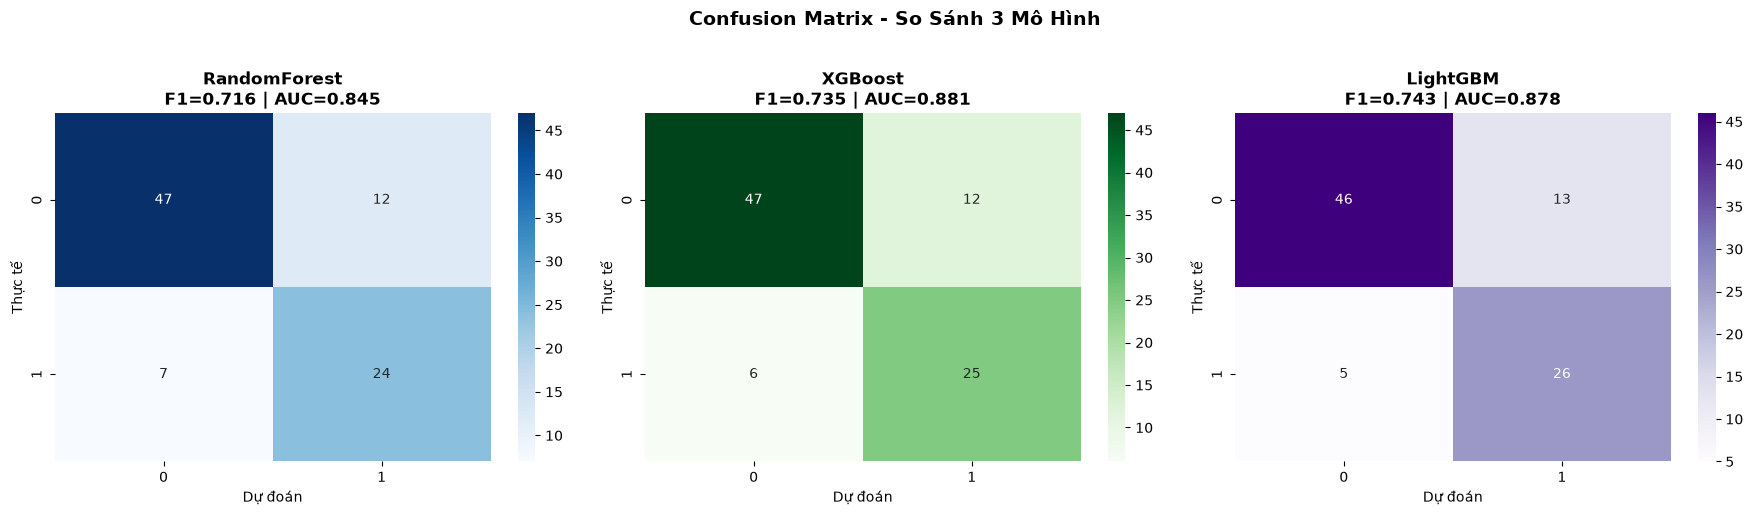


BẢNG SO SÁNH TỔNG HỢP 3 MÔ HÌNH
     Mô hình  Accuracy  Precision (Top10)  Recall (Top10)  F1 (Top10)  ROC-AUC   PR-AUC  Train F1  Train/Test Gap  Thời gian (s)
RandomForest  0.788889           0.666667        0.774194    0.716418 0.845271 0.724323  0.751825        0.035407           0.17
     XGBoost  0.800000           0.675676        0.806452    0.735294 0.881356 0.767920  0.837037        0.101743           0.09
    LightGBM  0.800000           0.666667        0.838710    0.742857 0.877529 0.786054  0.859259        0.116402           0.07

>>> Mô hình tốt nhất theo F1: LightGBM (F1 = 0.743)


In [84]:
import pandas as pd

# ===== Huấn luyện & đánh giá trên Train/Test Split =====
results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
cmaps = ['Blues', 'Greens', 'Purples']

for idx, (name, model) in enumerate(models.items()):
    t0 = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - t0
    
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_train_pred = model.predict(X_train)
    
    # Metrics
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results.append({
        'Mô hình': name,
        'Accuracy': report['accuracy'],
        'Precision (Top10)': report['1']['precision'],
        'Recall (Top10)': report['1']['recall'],
        'F1 (Top10)': report['1']['f1-score'],
        'ROC-AUC': roc,
        'PR-AUC': pr_auc,
        'Train F1': train_f1,
        'Train/Test Gap': train_f1 - test_f1,
        'Thời gian (s)': round(train_time, 2)
    })
    
    print(f'\n{"=" * 50}')
    print(f'{name}')
    print(f'{"=" * 50}')
    print(classification_report(y_test, y_pred))
    print(f'ROC-AUC: {roc:.3f} | PR-AUC: {pr_auc:.3f}')
    print(f'Train F1: {train_f1:.3f} | Test F1: {test_f1:.3f} | Gap: {train_f1 - test_f1:.3f}')
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmaps[idx], ax=axes[idx])
    axes[idx].set_title(f'{name}\nF1={test_f1:.3f} | AUC={roc:.3f}', fontweight='bold')
    axes[idx].set_xlabel('Dự đoán')
    axes[idx].set_ylabel('Thực tế')

plt.suptitle('Confusion Matrix - So Sánh 3 Mô Hình', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ===== Bảng so sánh tổng hợp =====
df_results = pd.DataFrame(results)
print('\n' + '=' * 80)
print('BẢNG SO SÁNH TỔNG HỢP 3 MÔ HÌNH')
print('=' * 80)
print(df_results.to_string(index=False))

# Highlight best model
best_model_name = df_results.loc[df_results['F1 (Top10)'].idxmax(), 'Mô hình']
best_f1 = df_results['F1 (Top10)'].max()
print(f'\n>>> Mô hình tốt nhất theo F1: {best_model_name} (F1 = {best_f1:.3f})')


### 7.3 Hyperparameter Tuning (GridSearchCV)

Tối ưu siêu tham số cho mô hình tốt nhất bằng **GridSearchCV** với **StratifiedKFold 5-fold**.


In [89]:
from sklearn.model_selection import GridSearchCV

# ===== Hyperparameter Tuning cho RandomForest =====
param_grid_rf = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [3, 4, 5],
    'classifier__min_samples_leaf': [4, 8, 12],
}

grid_rf = GridSearchCV(
    models['RandomForest'], param_grid_rf,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=0 # Chạy song song n_jobs=-1
)
grid_rf.fit(X_train, y_train)
print(f'[RandomForest] Best params: {grid_rf.best_params_}')
print(f'[RandomForest] Best CV F1: {grid_rf.best_score_:.3f}')

# ===== Hyperparameter Tuning cho XGBoost =====
param_grid_xgb = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [2, 3, 4],
    'classifier__learning_rate': [0.01, 0.05, 0.1],
}

grid_xgb = GridSearchCV(
    models['XGBoost'], param_grid_xgb,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=0
)
grid_xgb.fit(X_train, y_train)
print(f'\n[XGBoost] Best params: {grid_xgb.best_params_}')
print(f'[XGBoost] Best CV F1: {grid_xgb.best_score_:.3f}')

# ===== Hyperparameter Tuning cho LightGBM =====
param_grid_lgbm = {
    'classifier__n_estimators': [100, 200],
    'classifier__max_depth': [2, 3, 4],
    'classifier__num_leaves': [7, 11, 15], # Giảm num_leaves
    'classifier__min_child_samples': [10, 15, 20],
}

grid_lgbm = GridSearchCV(
    models['LightGBM'], param_grid_lgbm,
    cv=StratifiedKFold(5, shuffle=True, random_state=42),
    scoring='f1', n_jobs=-1, verbose=0
)
grid_lgbm.fit(X_train, y_train)
print(f'\n[LightGBM] Best params: {grid_lgbm.best_params_}')
print(f'[LightGBM] Best CV F1: {grid_lgbm.best_score_:.3f}')

# ===== Chọn mô hình tốt nhất =====
tuned_models = {
    'RandomForest': grid_rf.best_estimator_,
    'XGBoost': grid_xgb.best_estimator_,
    'LightGBM': grid_lgbm.best_estimator_,
}

best_name = max(tuned_models, key=lambda n: {
    'RandomForest': grid_rf.best_score_,
    'XGBoost': grid_xgb.best_score_,
    'LightGBM': grid_lgbm.best_score_}[n])
best_model = tuned_models[best_name]
print(f'\n>>> Mô hình tốt nhất sau tuning: {best_name}')


[RandomForest] Best params: {'classifier__max_depth': 4, 'classifier__min_samples_leaf': 4, 'classifier__n_estimators': 200}
[RandomForest] Best CV F1: 0.663

[XGBoost] Best params: {'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200}
[XGBoost] Best CV F1: 0.705

[LightGBM] Best params: {'classifier__max_depth': 2, 'classifier__min_child_samples': 15, 'classifier__n_estimators': 100, 'classifier__num_leaves': 7}
[LightGBM] Best CV F1: 0.698

>>> Mô hình tốt nhất sau tuning: XGBoost


### 7.4 ROC Curve & Precision-Recall Curve

So sánh trực quan khả năng phân tách của 3 mô hình đã được tối ưu (tuned).
- **ROC Curve**: Đánh giá khả năng phân biệt tổng thể.
- **PR Curve**: Phù hợp hơn ROC khi dữ liệu mất cân bằng (class imbalance).


d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


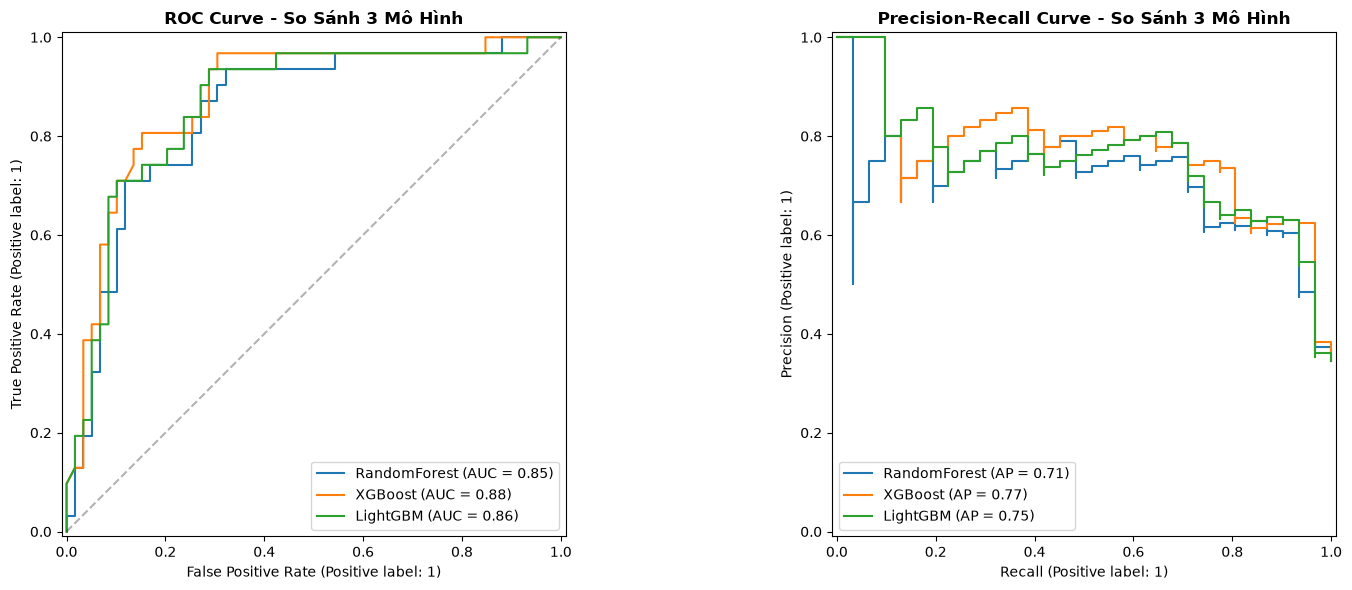

In [91]:
from sklearn.metrics import RocCurveDisplay, PrecisionRecallDisplay

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for idx, (name, model) in enumerate(tuned_models.items()):
    RocCurveDisplay.from_estimator(model, X_test, y_test,
                                   ax=axes[0], name=name)
    PrecisionRecallDisplay.from_estimator(model, X_test, y_test,
                                          ax=axes[1], name=name)

axes[0].set_title('ROC Curve - So Sánh 3 Mô Hình', fontweight='bold')
axes[0].plot([0, 1], [0, 1], 'k--', alpha=0.3)
axes[1].set_title('Precision-Recall Curve - So Sánh 3 Mô Hình', fontweight='bold')

plt.tight_layout()
plt.show()


### 7.5 Feature Importance (Mô hình tốt nhất)

Phân tích tầm quan trọng của từng đặc trưng theo mô hình tốt nhất.


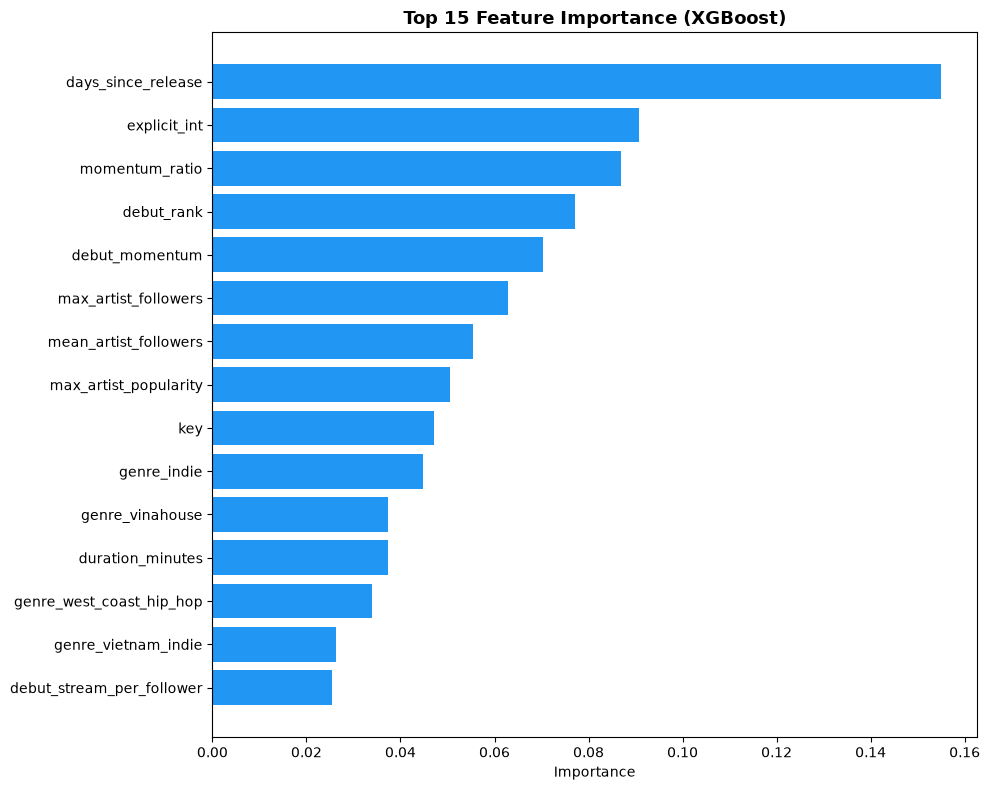


Top 5 features quan trọng nhất:
  days_since_release             : 0.1549
  explicit_int                   : 0.0907
  momentum_ratio                 : 0.0869
  debut_rank                     : 0.0772
  debut_momentum                 : 0.0703


In [92]:
# Lấy feature importances từ mô hình tốt nhất
classifier = best_model.named_steps['classifier']

# Lấy tên features sau preprocessing
feature_names = ml_features  # Tên gốc

if hasattr(classifier, 'feature_importances_'):
    importances = classifier.feature_importances_
    # Nếu số lượng importances khác feature_names, dùng index
    if len(importances) != len(feature_names):
        feature_names = [f'Feature_{i}' for i in range(len(importances))]
    
    feat_imp = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    }).sort_values('Importance', ascending=True).tail(15)
    
    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color='#2196F3')
    ax.set_title(f'Top 15 Feature Importance ({best_name})', fontweight='bold', fontsize=13)
    ax.set_xlabel('Importance')
    plt.tight_layout()
    plt.show()
    
    print(f'\nTop 5 features quan trọng nhất:')
    top5 = feat_imp.tail(5).iloc[::-1]
    for _, row in top5.iterrows():
        print(f'  {row["Feature"]:30s} : {row["Importance"]:.4f}')


### 7.6 Bảng So Sánh Tổng Hợp Sau Tuning


In [93]:
# ===== Đánh giá lại sau tuning =====
tuned_results = []

for name, model in tuned_models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    y_train_pred = model.predict(X_train)
    
    train_f1 = f1_score(y_train, y_train_pred)
    test_f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    pr_auc = average_precision_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    tuned_results.append({
        'Mô hình': name,
        'Accuracy': round(report['accuracy'], 3),
        'Precision': round(report['1']['precision'], 3),
        'Recall': round(report['1']['recall'], 3),
        'F1': round(test_f1, 3),
        'ROC-AUC': round(roc, 3),
        'PR-AUC': round(pr_auc, 3),
        'Train F1': round(train_f1, 3),
        'Gap': round(train_f1 - test_f1, 3),
    })

df_tuned = pd.DataFrame(tuned_results)
print('=' * 80)
print('BẢNG SO SÁNH SAU HYPERPARAMETER TUNING')
print('=' * 80)
print(df_tuned.to_string(index=False))

best_final = df_tuned.loc[df_tuned['F1'].idxmax(), 'Mô hình']
print(f'\n>>> MÔ HÌNH CUỐI CÙNG ĐƯỢC CHỌN: {best_final}')
print(f'    F1 = {df_tuned["F1"].max():.3f} | ROC-AUC = {df_tuned.loc[df_tuned["F1"].idxmax(), "ROC-AUC"]:.3f}')


BẢNG SO SÁNH SAU HYPERPARAMETER TUNING
     Mô hình  Accuracy  Precision  Recall    F1  ROC-AUC  PR-AUC  Train F1   Gap
RandomForest     0.800      0.697   0.742 0.719    0.849   0.707     0.774 0.056
     XGBoost     0.800      0.676   0.806 0.735    0.880   0.771     0.796 0.060
    LightGBM     0.778      0.634   0.839 0.722    0.865   0.753     0.801 0.079

>>> MÔ HÌNH CUỐI CÙNG ĐƯỢC CHỌN: XGBoost
    F1 = 0.735 | ROC-AUC = 0.880


d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
d:\ML_project\.venv\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


## 8. Kết Luận

### Tóm tắt kết quả
- Ba mô hình **RandomForest**, **XGBoost**, và **LightGBM** đã được huấn luyện và so sánh công bằng bằng **StratifiedKFold 5-Fold Cross-Validation** kết hợp **SMOTE**.
- Hyperparameter tuning bằng **GridSearchCV** đã cải thiện hiệu suất.
- Mô hình cuối cùng được lưu để phục vụ triển khai (deployment).

### Các đặc trưng quan trọng nhất
- **Nhóm quỹ đạo (Trajectory):** `debut_streams`, `debut_rank`, `debut_momentum` — tín hiệu mạnh nhất cho dự đoán Top 10.
- **Nhóm nghệ sĩ (Artist):** `artist_popularity`, `artist_followers` — fandom và độ phủ sóng định hình khả năng lên Top.
- **Nhóm âm thanh (Audio):** Đóng góp ít hơn nhưng vẫn có giá trị bổ sung.

### Hạn chế
- Bộ dữ liệu nhỏ (446 tracks) giới hạn khả năng tổng quát hóa.
- Yếu tố marketing, viral, xu hướng xã hội không thể đo lường bằng audio features.
- `debut_rank` tương quan chỉ 0.51 với `peak_rank` — giới hạn lý thuyết F1 ≈ 0.78-0.82.

### Hướng cải thiện
- Thu thập thêm dữ liệu (nhiều tuần, nhiều quốc gia).
- Tích hợp dữ liệu mạng xã hội (TikTok views, YouTube trending).
- Thử nghiệm Stacking Ensemble kết hợp 3 mô hình.
